In [1]:
import yfinance as yf

gc = yf.download(
    "GC=F",
    start="2023-01-01",
    end="2026-01-01",
    auto_adjust=False
)

gc.to_csv("COMEX_GC_2023_2025.csv")

[*********************100%***********************]  1 of 1 completed


In [2]:
gc

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2023-01-03,1839.699951,1839.699951,1839.699951,1836.199951,1836.199951,29
2023-01-04,1852.800049,1852.800049,1859.099976,1845.599976,1845.599976,25
2023-01-05,1834.800049,1834.800049,1855.199951,1834.800049,1855.199951,24
2023-01-06,1864.199951,1864.199951,1868.199951,1835.300049,1838.400024,26
2023-01-09,1872.699951,1872.699951,1880.000000,1867.000000,1867.000000,62
...,...,...,...,...,...,...
2025-12-24,4480.600098,4480.600098,4503.399902,4468.399902,4500.700195,500
2025-12-26,4529.100098,4529.100098,4556.299805,4502.000000,4512.000000,263


In [3]:
import akshare as ak

sge = ak.spot_hist_sge(symbol="Au99.99")

sge.to_csv("SGE_Au9999_2016_2026.csv", index=False)

In [4]:
sge

,date,open,close,low,high
0,2016-12-19,262.45,262.76,262.02,263.50
1,2016-12-20,262.88,262.06,261.42,263.70
2,2016-12-21,262.40,260.97,258.60,262.65
3,2016-12-22,261.18,260.00,259.05,261.18
4,2016-12-23,258.95,260.07,258.70,260.37
...,...,...,...,...,...
2359,2026-09-08,949.00,951.52,948.00,959.94
2360,2026-09-09,950.00,951.77,941.00,952.80
2361,2026-09-10,952.00,952.99,945.51,957.00
2362,2026-09-11,946.50,939.54,929.00,952.00


In [5]:
import akshare as ak

df = ak.get_shfe_daily()
print(df.head())

   index  symbol      date   open   high    low  close  volume open_interest  \
0      0  CU2204  20220415  74500  75700  74270  75700    3010          6400   
1      1  CU2205  20220415  73820  75100  73780  74970   67161        164995   
2      2  CU2206  20220415  73800  74860  73560  74740   38115        109683   
3      3  CU2207  20220415  73450  74650  73380  74540    9135         45694   
4      4  CU2208  20220415  73380  74500  73300  74390    2744         19550   

      turnover settle pre_settle variety  
0   113014.350  75090      74280      CU  
1  2503692.985  74550      73940      CU  
2  1416717.855  74330      73740      CU  
3   338613.110  74130      73590      CU  
4   101406.455  73910      73480      CU  


In [6]:
import akshare as ak

In [7]:
df = ak.get_shfe_daily(date="20250102")
df.head(20)

,index,symbol,date,open,high,low,close,volume,open_interest,turnover,settle,pre_settle,variety
0,0,CU2501,20250102,73480,73480,73000,73300,19700,42570,722345.750,73330,73800,CU
1,1,CU2502,20250102,73310,73440,73030,73280,48466,156644,1776482.870,73300,73800,CU
2,2,CU2503,20250102,73410,73510,73110,73380,21079,113930,773495.270,73390,73890,CU
3,3,CU2504,20250102,73500,73610,73200,73500,10060,42554,369695.265,73490,73990,CU
4,4,CU2505,20250102,73700,73720,73250,73580,4762,21549,175247.115,73600,74070,CU
5,5,CU2506,20250102,73660,73760,73410,73680,902,8404,33216.505,73650,74130,CU
6,6,CU2507,20250102,73650,73830,73410,73700,381,3652,14043.340,73710,74160,CU
7,7,CU2508,20250102,73580,73830,73450,73720,218,1798,8036.250,73720,74190,CU
8,8,CU2509,20250102,73620,73840,73490,73700,154,1774,5676.950,73720,74200,CU
9,9,CU2510,20250102,73520,73880,73520,73740,163,1051,6011.495,73760,74190,CU


In [8]:
import pandas as pd
import time
import os

start_date = pd.Timestamp("2023-01-01")
end_date = pd.Timestamp("2025-12-31")

all_gold = []

dates = pd.date_range(start_date, end_date, freq="D")

print(f"Downloading SHFE Gold data for {len(dates)} calendar days...")
print("Please wait — do not close the notebook.\n")

for i, date in enumerate(dates, 1):
    date_str = date.strftime("%Y%m%d")

    try:
        df = ak.get_shfe_daily(date=date_str)

        if df is not None and not df.empty:

            # Keep only SHFE Gold futures
            gold = df[
                df["variety"].astype(str).str.upper() == "AU"
            ].copy()

            if not gold.empty:
                all_gold.append(gold)

                print(
                    f"{date_str}  →  {len(gold)} Gold contracts"
                )

    except Exception as e:
        print(f"{date_str}  → ERROR: {e}")

    time.sleep(0.05)

print("\nCombining data...")

if all_gold:
    shfe_gold = pd.concat(all_gold, ignore_index=True)

    shfe_gold = shfe_gold.drop_duplicates()

    shfe_gold = shfe_gold.sort_values(
        ["date", "symbol"]
    ).reset_index(drop=True)

    output_file = os.path.join(
        os.getcwd(),
        "SHFE_Gold_2023_2025_raw.csv"
    )

    shfe_gold.to_csv(
        output_file,
        index=False,
        encoding="utf-8-sig"
    )

    print("\n" + "="*60)
    print("SHFE GOLD DOWNLOAD COMPLETE")
    print("="*60)
    print("Rows:", len(shfe_gold))
    print("Contracts:", shfe_gold["symbol"].nunique())
    print("First date:", shfe_gold["date"].min())
    print("Last date:", shfe_gold["date"].max())
    print("Saved to:")
    print(output_file)

else:
    print("NO GOLD DATA WAS FOUND.")

Please wait — do not close the notebook.

20230103  →  8 Gold contracts
20230104  →  8 Gold contracts
20230105  →  8 Gold contracts
20230106  →  8 Gold contracts
20230109  →  8 Gold contracts
20230110  →  8 Gold contracts
20230111  →  8 Gold contracts
20230112  →  8 Gold contracts
20230113  →  8 Gold contracts
20230116  →  8 Gold contracts
20230117  →  8 Gold contracts
20230118  →  8 Gold contracts
20230119  →  8 Gold contracts
20230120  →  8 Gold contracts
20230130  →  8 Gold contracts
20230131  →  8 Gold contracts
20230201  →  8 Gold contracts
第1次链接失败, 最多尝试 20 次
20230202  →  8 Gold contracts
20230203  →  8 Gold contracts
20230206  →  8 Gold contracts
20230207  →  8 Gold contracts
20230208  →  8 Gold contracts
20230209  →  8 Gold contracts
20230210  →  8 Gold contracts
20230213  →  8 Gold contracts
第1次链接失败, 最多尝试 20 次
20230214  →  8 Gold contracts
20230215  →  8 Gold contracts
20230216  →  8 Gold contracts
20230217  →  8 Gold contracts
20230220  →  8 Gold contracts
20230221  →  8 Gold 

In [14]:
import requests
import pandas as pd

url = "https://prices.lbma.org.uk/json/gold_pm.json"

response = requests.get(url, timeout=30)

print("Status:", response.status_code)
print("Bytes:", len(response.content))

response.raise_for_status()

data = response.json()

print("Records:", len(data))
print("First record:", data[0])
print("Last record:", data[-1])

Status: 200
Bytes: 914390
Records: 14681
First record: {'is_cms_locked': 0, 'd': '1968-04-01', 'v': [37.7, 15.68, None]}
Last record: {'is_cms_locked': 0, 'd': '2026-09-11', 'v': [4386.25, 3241.88, 3777]}


In [15]:
import pandas as pd
import requests

url = "https://prices.lbma.org.uk/json/gold_pm.json"

response = requests.get(url, timeout=30)
response.raise_for_status()

data = response.json()

lbma_raw = pd.DataFrame([
    {
        "Date": x["d"],
        "LBMA_Gold_PM_USD": x["v"][0],
        "LBMA_Gold_PM_GBP": x["v"][1],
        "LBMA_Gold_PM_EUR": x["v"][2]
    }
    for x in data
])

lbma_raw["Date"] = pd.to_datetime(lbma_raw["Date"])

# Save untouched historical extraction
lbma_raw.to_csv(
    "LBMA_Gold_PM_raw.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Raw rows:", len(lbma_raw))
print("First date:", lbma_raw["Date"].min())
print("Last date:", lbma_raw["Date"].max())

print("\nColumns:")
print(lbma_raw.columns.tolist())

print("\nSample:")
print(lbma_raw.head())

print("\nLast 5:")
print(lbma_raw.tail())

Raw rows: 14681
First date: 1968-04-01 00:00:00
Last date: 2026-09-11 00:00:00

Columns:
['Date', 'LBMA_Gold_PM_USD', 'LBMA_Gold_PM_GBP', 'LBMA_Gold_PM_EUR']

Sample:
        Date  LBMA_Gold_PM_USD  LBMA_Gold_PM_GBP  LBMA_Gold_PM_EUR
0 1968-04-01             37.70             15.68               NaN
1 1968-04-02             37.30             37.30               NaN
2 1968-04-03             37.60             15.63               NaN
3 1968-04-04             36.95             15.36               NaN
4 1968-04-05             37.00             15.39               NaN

Last 5:
            Date  LBMA_Gold_PM_USD  LBMA_Gold_PM_GBP  LBMA_Gold_PM_EUR
14676 2026-09-07           4402.55           3252.16           3786.19
14677 2026-09-08           4399.10           3246.10           3784.55
14678 2026-09-09           4414.90           3256.43           3790.63
14679 2026-09-10           4365.45           3229.56           3759.09
14680 2026-09-11           4386.25           3241.88           3777

In [16]:
lbma_2023_2025 = lbma_raw[
    (lbma_raw["Date"] >= "2023-01-01") &
    (lbma_raw["Date"] <= "2025-12-31")
].copy()

lbma_2023_2025.to_csv(
    "LBMA_Gold_PM_2023_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Research-period rows:", len(lbma_2023_2025))
print("Research start:", lbma_2023_2025["Date"].min())
print("Research end:", lbma_2023_2025["Date"].max())

print("\nMissing USD values:",
      lbma_2023_2025["LBMA_Gold_PM_USD"].isna().sum())

print("\nDuplicate dates:",
      lbma_2023_2025["Date"].duplicated().sum())

print("\nSample:")
print(lbma_2023_2025.head())

print("\nLast 5:")
print(lbma_2023_2025.tail())

Research-period rows: 752
Research start: 2023-01-03 00:00:00
Research end: 2025-12-30 00:00:00

Missing USD values: 0

Duplicate dates: 0

Sample:
            Date  LBMA_Gold_PM_USD  LBMA_Gold_PM_GBP  LBMA_Gold_PM_EUR
13753 2023-01-03           1843.25           1532.29           1743.16
13754 2023-01-04           1857.30           1540.26           1749.58
13755 2023-01-05           1834.00           1540.01           1740.47
13756 2023-01-06           1852.20           1551.77           1758.11
13757 2023-01-09           1878.85           1541.03           1750.71

Last 5:
            Date  LBMA_Gold_PM_USD  LBMA_Gold_PM_GBP  LBMA_Gold_PM_EUR
14500 2025-12-19           4337.60           3244.09           3699.11
14501 2025-12-22           4421.65           3287.50           3758.84
14502 2025-12-23           4449.40           3300.12           3780.66
14503 2025-12-29           4337.05           3212.89           3680.42
14504 2025-12-30           4367.80           3240.91          

# PHASE 2 — DATA CLEANING & STANDARDIZATION

## Step 2.1 — Load Acquired Raw Datasets

Study Period: 2023-01-01 to 2025-12-31

Purpose:
- Load previously acquired datasets
- Preserve raw files unchanged
- Inspect structure before cleaning
- Prepare datasets for standardized research series

In [19]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# STEP 2.1 — LOAD ACQUIRED DATASETS
# ============================================================

DATA_DIR = Path(r"Global Gold Research")

# Raw / acquired files
comex_file = DATA_DIR / "COMEX_GC_2023_2025.csv"
lbma_file = DATA_DIR / "LBMA_Gold_PM_2023_2025.csv"
shfe_file = DATA_DIR / "SHFE_Gold_2023_2025_raw.csv"
sge_file = DATA_DIR / "SGE_Au9999_2016_2026.csv"

mcx_refined_file = DATA_DIR / "Refined Gold Historical Data.csv"
mcx_bhavcopy_file = DATA_DIR / "gold_bhavcopy (1).csv"

# Load
comex_raw = pd.read_csv(comex_file)
lbma_raw = pd.read_csv(lbma_file)
shfe_raw = pd.read_csv(shfe_file)
sge_raw = pd.read_csv(sge_file)

mcx_refined_raw = pd.read_csv(mcx_refined_file)
mcx_bhavcopy_raw = pd.read_csv(mcx_bhavcopy_file)

print("DATASETS LOADED")
print("=" * 60)

datasets = {
    "COMEX": comex_raw,
    "LBMA": lbma_raw,
    "SHFE": shfe_raw,
    "SGE": sge_raw,
    "MCX Refined": mcx_refined_raw,
    "MCX Bhavcopy": mcx_bhavcopy_raw
}

for name, df in datasets.items():
    print(f"{name:15} → {df.shape[0]:,} rows × {df.shape[1]} columns")

DATASETS LOADED
COMEX           → 756 rows × 7 columns
LBMA            → 752 rows × 4 columns
SHFE            → 5,816 rows × 13 columns
SGE             → 2,364 rows × 5 columns
MCX Refined     → 2,760 rows × 7 columns
MCX Bhavcopy    → 252 rows × 17 columns


In [20]:
# ============================================================
# STEP 2.2 — BASIC STRUCTURAL AUDIT
# IMPORTANT: This cell ONLY READS the raw data.
# It does NOT modify, clean, or overwrite any original files.
# ============================================================

for name, df in datasets.items():

    print("\n" + "=" * 75)
    print(name)
    print("=" * 75)

    print("Shape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData types:")
    print(df.dtypes)

    print("\nMissing values:")
    print(df.isna().sum())

    print("\nDuplicate rows:", df.duplicated().sum())

    print("\nFirst 3 rows:")
    display(df.head(3))


COMEX
Shape: (756, 7)

Columns:
['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Data types:
Price        object
Adj Close    object
Close        object
High         object
Low          object
Open         object
Volume       object
dtype: object

Missing values:
Price        0
Adj Close    1
Close        1
High         1
Low          1
Open         1
Volume       1
dtype: int64

Duplicate rows: 0

First 3 rows:


,Price,Adj Close,Close,High,Low,Open,Volume
0,Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
1,Date,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-01-03,1839.699951171875,1839.699951171875,1839.699951171875,1836.199951171875,1836.199951171875,29



LBMA
Shape: (752, 4)

Columns:
['Date', 'LBMA_Gold_PM_USD', 'LBMA_Gold_PM_GBP', 'LBMA_Gold_PM_EUR']

Data types:
Date                 object
LBMA_Gold_PM_USD    float64
LBMA_Gold_PM_GBP    float64
LBMA_Gold_PM_EUR    float64
dtype: object

Missing values:
Date                0
LBMA_Gold_PM_USD    0
LBMA_Gold_PM_GBP    0
LBMA_Gold_PM_EUR    0
dtype: int64

Duplicate rows: 0

First 3 rows:


,Date,LBMA_Gold_PM_USD,LBMA_Gold_PM_GBP,LBMA_Gold_PM_EUR
0,2023-01-03,1843.25,1532.29,1743.16
1,2023-01-04,1857.30,1540.26,1749.58
2,2023-01-05,1834.00,1540.01,1740.47



SHFE
Shape: (5816, 13)

Columns:
['index', 'symbol', 'date', 'open', 'high', 'low', 'close', 'volume', 'open_interest', 'turnover', 'settle', 'pre_settle', 'variety']

Data types:
index              int64
symbol            object
date               int64
open             float64
high             float64
low              float64
close            float64
volume             int64
open_interest      int64
turnover         float64
settle           float64
pre_settle       float64
variety           object
dtype: object

Missing values:
index             0
symbol            0
date              0
open             78
high             78
low              78
close             0
volume            0
open_interest     0
turnover          0
settle            0
pre_settle        0
variety           0
dtype: int64

Duplicate rows: 0

First 3 rows:


...

,date,open,close,low,high
0,2016-12-19,262.45,262.76,262.02,263.50
1,2016-12-20,262.88,262.06,261.42,263.70
2,2016-12-21,262.40,260.97,258.60,262.65



MCX Refined
Shape: (2760, 7)

Columns:
['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

Data types:
Date        object
Price       object
Open        object
High        object
Low         object
Vol.        object
Change %    object
dtype: object

Missing values:
Date         0
Price        0
Open         0
High         0
Low          0
Vol.        22
Change %     0
dtype: int64

Duplicate rows: 0

First 3 rows:


,Date,Price,Open,High,Low,Vol.,Change %
0,30-08-2024,"71,864","71,900","71,909","71,856",0.45K,-0.45%
1,29-08-2024,"72,188","71,880","72,249","71,700",7.88K,0.62%
2,28-08-2024,"71,743","71,980","72,075","71,514",6.19K,-0.53%



MCX Bhavcopy
Shape: (252, 17)

Columns:
['__type', 'Date', 'Symbol', 'ExpiryDate', 'Open', 'High', 'Low', 'Close', 'PreviousClose', 'Volume', 'VolumeInThousands', 'Value', 'OpenInterest', 'DateDisplay', 'InstrumentName', 'StrikePrice', 'OptionType']

Data types:
__type                object
Date                  object
Symbol                object
ExpiryDate            object
Open                 float64
High                 float64
Low                  float64
Close                float64
PreviousClose        float64
Volume                 int64
VolumeInThousands     object
Value                float64
OpenInterest           int64
DateDisplay          float64
InstrumentName        object
StrikePrice          float64
OptionType            object
dtype: object

Missing values:
__type                 0
Date                   0
Symbol                 0
ExpiryDate             0
Open                   0
High                   0
Low                    0
Close                  0
PreviousClos

,__type,Date,Symbol,ExpiryDate,Open,High,Low,Close,PreviousClose,Volume,VolumeInThousands,Value,OpenInterest,DateDisplay,InstrumentName,StrikePrice,OptionType
0,MCX.BL.Bhavcopy,2025-12-05,GOLD,05DEC2025,127581.0,129032.0,127581.0,128425.0,127300.0,14,14.000 GRMS,1796.45,22,NaN,FUTCOM,0.0,-
1,MCX.BL.Bhavcopy,2025-12-04,GOLD,05DEC2025,127950.0,128217.0,126872.0,127300.0,127832.0,16,16.000 GRMS,2040.69,26,NaN,FUTCOM,0.0,-
2,MCX.BL.Bhavcopy,2025-12-03,GOLD,05DEC2025,128120.0,128120.0,127555.0,127832.0,127334.0,48,48.000 GRMS,6136.39,80,NaN,FUTCOM,0.0,-


In [21]:
# ============================================================
# STEP 2.3 — DATE COVERAGE AUDIT
# IMPORTANT:
# This cell ONLY READS the raw data.
# It does NOT modify or overwrite any original files.
# ============================================================

print("=" * 75)
print("DATE COVERAGE AUDIT")
print("=" * 75)

# COMEX
comex_dates = pd.to_datetime(
    comex_raw["Price"].where(comex_raw["Price"] != "Date"),
    errors="coerce"
)

# LBMA
lbma_dates = pd.to_datetime(
    lbma_raw["Date"],
    errors="coerce"
)

# SHFE
shfe_dates = pd.to_datetime(
    shfe_raw["date"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# SGE
sge_dates = pd.to_datetime(
    sge_raw["date"],
    errors="coerce"
)

# MCX Refined
mcx_refined_dates = pd.to_datetime(
    mcx_refined_raw["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

# MCX Bhavcopy
mcx_bhav_dates = pd.to_datetime(
    mcx_bhavcopy_raw["Date"],
    errors="coerce"
)

coverage = pd.DataFrame({
    "Market": [
        "COMEX",
        "LBMA",
        "SHFE",
        "SGE",
        "MCX Refined",
        "MCX Bhavcopy"
    ],
    "First Date": [
        comex_dates.min(),
        lbma_dates.min(),
        shfe_dates.min(),
        sge_dates.min(),
        mcx_refined_dates.min(),
        mcx_bhav_dates.min()
    ],
    "Last Date": [
        comex_dates.max(),
        lbma_dates.max(),
        shfe_dates.max(),
        sge_dates.max(),
        mcx_refined_dates.max(),
        mcx_bhav_dates.max()
    ],
    "Invalid Dates": [
        comex_dates.isna().sum(),
        lbma_dates.isna().sum(),
        shfe_dates.isna().sum(),
        sge_dates.isna().sum(),
        mcx_refined_dates.isna().sum(),
        mcx_bhav_dates.isna().sum()
    ]
})

display(coverage)

DATE COVERAGE AUDIT


C:\Users\Divesh\AppData\Local\Temp\ipykernel_14732\2243952984.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  comex_dates = pd.to_datetime(


,Market,First Date,Last Date,Invalid Dates
0,COMEX,2023-01-03,2025-12-31,2
1,LBMA,2023-01-03,2025-12-30,0
2,SHFE,2023-01-03,2025-12-31,0
3,SGE,2016-12-19,2026-09-14,0
4,MCX Refined,2014-01-01,2024-08-30,0
5,MCX Bhavcopy,2024-12-16,2025-12-05,0


In [22]:
# ============================================================
# STEP 2.4A — CREATE SAFE WORKING COPIES
# IMPORTANT:
# Original/raw DataFrames are NOT modified.
# All future cleaning will be performed on *_work copies.
# ============================================================

comex_work = comex_raw.copy(deep=True)
lbma_work = lbma_raw.copy(deep=True)
shfe_work = shfe_raw.copy(deep=True)
sge_work = sge_raw.copy(deep=True)

mcx_refined_work = mcx_refined_raw.copy(deep=True)
mcx_bhavcopy_work = mcx_bhavcopy_raw.copy(deep=True)

working_datasets = {
    "COMEX": comex_work,
    "LBMA": lbma_work,
    "SHFE": shfe_work,
    "SGE": sge_work,
    "MCX Refined": mcx_refined_work,
    "MCX Bhavcopy": mcx_bhavcopy_work
}

print("=" * 75)
print("SAFE WORKING COPIES CREATED")
print("=" * 75)

for name, df in working_datasets.items():
    print(f"{name:15} → {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\nOriginal datasets remain untouched.")
print("All future transformations will be performed on *_work copies.")

SAFE WORKING COPIES CREATED
COMEX           → 756 rows × 7 columns
LBMA            → 752 rows × 4 columns
SHFE            → 5,816 rows × 13 columns
SGE             → 2,364 rows × 5 columns
MCX Refined     → 2,760 rows × 7 columns
MCX Bhavcopy    → 252 rows × 17 columns

Original datasets remain untouched.
All future transformations will be performed on *_work copies.


In [23]:
# ============================================================
# STEP 2.4B — COMEX CLEANING
# IMPORTANT:
# Only comex_work is modified.
# comex_raw remains completely untouched.
# ============================================================

print("=" * 75)
print("COMEX CLEANING")
print("=" * 75)

# ------------------------------------------------------------
# 1. Inspect the first few rows before cleaning
# ------------------------------------------------------------

print("\nBefore cleaning:")
display(comex_work.head(5))

# ------------------------------------------------------------
# 2. Remove the two metadata rows
#    Row 0 = Ticker
#    Row 1 = Date
# ------------------------------------------------------------

comex_work = comex_work.iloc[2:].copy()

# ------------------------------------------------------------
# 3. Rename the first column to Date
# ------------------------------------------------------------

comex_work = comex_work.rename(columns={"Price": "Date"})

# ------------------------------------------------------------
# 4. Convert Date to datetime
# ------------------------------------------------------------

comex_work["Date"] = pd.to_datetime(
    comex_work["Date"],
    errors="coerce"
)

# ------------------------------------------------------------
# 5. Convert market columns to numeric
# ------------------------------------------------------------

numeric_columns = [
    "Adj Close",
    "Close",
    "High",
    "Low",
    "Open",
    "Volume"
]

for column in numeric_columns:
    comex_work[column] = pd.to_numeric(
        comex_work[column],
        errors="coerce"
    )

# ------------------------------------------------------------
# 6. Reset the index
# ------------------------------------------------------------

comex_work = comex_work.reset_index(drop=True)

# ------------------------------------------------------------
# 7. Display result
# ------------------------------------------------------------

print("\nAfter cleaning:")
print("Shape:", comex_work.shape)

print("\nData types:")
print(comex_work.dtypes)

print("\nMissing values:")
print(comex_work.isna().sum())

print("\nFirst 3 rows:")
display(comex_work.head(3))

print("\nLast 3 rows:")
display(comex_work.tail(3))

COMEX CLEANING

Before cleaning:


,Price,Adj Close,Close,High,Low,Open,Volume
0,Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
1,Date,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-01-03,1839.699951171875,1839.699951171875,1839.699951171875,1836.199951171875,1836.199951171875,29
3,2023-01-04,1852.800048828125,1852.800048828125,1859.0999755859375,1845.5999755859375,1845.5999755859375,25
4,2023-01-05,1834.800048828125,1834.800048828125,1855.199951171875,1834.800048828125,1855.199951171875,24



After cleaning:
Shape: (754, 7)

Data types:
Date         datetime64[ns]
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
dtype: object

Missing values:
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

First 3 rows:


,Date,Adj Close,Close,High,Low,Open,Volume
0,2023-01-03,1839.699951,1839.699951,1839.699951,1836.199951,1836.199951,29
1,2023-01-04,1852.800049,1852.800049,1859.099976,1845.599976,1845.599976,25
2,2023-01-05,1834.800049,1834.800049,1855.199951,1834.800049,1855.199951,24



Last 3 rows:


,Date,Adj Close,Close,High,Low,Open,Volume
751,2025-12-29,4325.100098,4325.100098,4379.000000,4325.100098,4371.500000,2044
752,2025-12-30,4370.100098,4370.100098,4403.600098,4338.000000,4346.399902,1837
753,2025-12-31,4325.600098,4325.600098,4363.799805,4285.000000,4333.500000,785


In [24]:
# ============================================================
# STEP 2.4C — LBMA CLEANING
# IMPORTANT:
# Only lbma_work is modified.
# lbma_raw remains completely untouched.
# ============================================================

print("=" * 75)
print("LBMA CLEANING")
print("=" * 75)

# ------------------------------------------------------------
# 1. Convert Date to datetime
# ------------------------------------------------------------

lbma_work["Date"] = pd.to_datetime(
    lbma_work["Date"],
    errors="coerce"
)

# ------------------------------------------------------------
# 2. Convert price columns to numeric
# ------------------------------------------------------------

lbma_price_columns = [
    "LBMA_Gold_PM_USD",
    "LBMA_Gold_PM_GBP",
    "LBMA_Gold_PM_EUR"
]

for column in lbma_price_columns:
    lbma_work[column] = pd.to_numeric(
        lbma_work[column],
        errors="coerce"
    )

# ------------------------------------------------------------
# 3. Sort by Date
# ------------------------------------------------------------

lbma_work = lbma_work.sort_values(
    "Date"
).reset_index(drop=True)

# ------------------------------------------------------------
# 4. Verification
# ------------------------------------------------------------

print("\nShape:", lbma_work.shape)

print("\nData types:")
print(lbma_work.dtypes)

print("\nMissing values:")
print(lbma_work.isna().sum())

print("\nDuplicate dates:",
      lbma_work["Date"].duplicated().sum())

print("\nFirst 3 rows:")
display(lbma_work.head(3))

print("\nLast 3 rows:")
display(lbma_work.tail(3))

LBMA CLEANING

Shape: (752, 4)

Data types:
Date                datetime64[ns]
LBMA_Gold_PM_USD           float64
LBMA_Gold_PM_GBP           float64
LBMA_Gold_PM_EUR           float64
dtype: object

Missing values:
Date                0
LBMA_Gold_PM_USD    0
LBMA_Gold_PM_GBP    0
LBMA_Gold_PM_EUR    0
dtype: int64

Duplicate dates: 0

First 3 rows:


,Date,LBMA_Gold_PM_USD,LBMA_Gold_PM_GBP,LBMA_Gold_PM_EUR
0,2023-01-03,1843.25,1532.29,1743.16
1,2023-01-04,1857.30,1540.26,1749.58
2,2023-01-05,1834.00,1540.01,1740.47



Last 3 rows:


,Date,LBMA_Gold_PM_USD,LBMA_Gold_PM_GBP,LBMA_Gold_PM_EUR
749,2025-12-23,4449.40,3300.12,3780.66
750,2025-12-29,4337.05,3212.89,3680.42
751,2025-12-30,4367.80,3240.91,3712.63


In [25]:
# ============================================================
# STEP 2.4D — SHFE CONTRACT STRUCTURE AUDIT
# IMPORTANT:
# This cell ONLY INSPECTS the working copy.
# No original/raw data is modified.
# ============================================================

print("=" * 75)
print("SHFE CONTRACT STRUCTURE AUDIT")
print("=" * 75)

# ------------------------------------------------------------
# 1. Number of unique contracts
# ------------------------------------------------------------

print("\nNumber of unique contracts:")
print(shfe_work["symbol"].nunique())

# ------------------------------------------------------------
# 2. List all contracts
# ------------------------------------------------------------

print("\nContracts:")
print(shfe_work["symbol"].unique())

# ------------------------------------------------------------
# 3. Number of observations per contract
# ------------------------------------------------------------

contract_counts = (
    shfe_work["symbol"]
    .value_counts()
    .sort_index()
)

print("\nObservations per contract:")
display(contract_counts.to_frame("Observations"))

# ------------------------------------------------------------
# 4. Date range for each contract
# ------------------------------------------------------------

contract_coverage = (
    shfe_work
    .groupby("symbol")["date"]
    .agg(["min", "max", "count"])
    .reset_index()
)

contract_coverage.columns = [
    "Contract",
    "First_Date",
    "Last_Date",
    "Observations"
]

print("\nContract date coverage:")
display(contract_coverage)

# ------------------------------------------------------------
# 5. Check how many contracts exist on each trading date
# ------------------------------------------------------------

contracts_per_date = (
    shfe_work
    .groupby("date")["symbol"]
    .nunique()
)

print("\nContracts per date — summary:")
print(contracts_per_date.describe())

print("\nFirst 10 dates and number of contracts:")
display(contracts_per_date.head(10).to_frame("Number_of_Contracts"))

# ------------------------------------------------------------
# 6. Check missing OHLC values by contract
# ------------------------------------------------------------

print("\nMissing OHLC values by contract:")

shfe_missing = (
    shfe_work
    .groupby("symbol")[["open", "high", "low", "close", "settle"]]
    .apply(lambda x: x.isna().sum())
)

display(shfe_missing)

SHFE CONTRACT STRUCTURE AUDIT

Number of unique contracts:
44

Contracts:
['AU2301' 'AU2302' 'AU2303' 'AU2304' 'AU2306' 'AU2308' 'AU2310' 'AU2312'
 'AU2402' 'AU2305' 'AU2404' 'AU2307' 'AU2406' 'AU2309' 'AU2408' 'AU2311'
 'AU2410' 'AU2401' 'AU2412' 'AU2403' 'AU2502' 'AU2405' 'AU2504' 'AU2407'
 'AU2506' 'AU2409' 'AU2508' 'AU2411' 'AU2510' 'AU2501' 'AU2512' 'AU2503'
 'AU2602' 'AU2505' 'AU2604' 'AU2507' 'AU2606' 'AU2509' 'AU2608' 'AU2511'
 'AU2610' 'AU2601' 'AU2612' 'AU2603']

Observations per contract:


,Observations
symbol,
AU2301,10
AU2302,27
AU2303,47
AU2304,69
AU2305,59
AU2306,109
AU2307,60
AU2308,150
AU2309,64



Contract date coverage:


,Contract,First_Date,Last_Date,Observations
0,AU2301,20230103,20230116,10
1,AU2302,20230103,20230215,27
2,AU2303,20230103,20230315,47
3,AU2304,20230103,20230417,69
4,AU2305,20230216,20230515,59
5,AU2306,20230103,20230615,109
6,AU2307,20230418,20230717,60
7,AU2308,20230103,20230815,150
8,AU2309,20230616,20230915,64
9,AU2310,20230103,20231016,188



Contracts per date — summary:
count    727.0
mean       8.0
std        0.0
min        8.0
25%        8.0
50%        8.0
75%        8.0
max        8.0
Name: symbol, dtype: float64

First 10 dates and number of contracts:


,Number_of_Contracts
date,
20230103,8
20230104,8
20230105,8
20230106,8
20230109,8
20230110,8
20230111,8
20230112,8
20230113,8



Missing OHLC values by contract:


,open,high,low,close,settle
symbol,,,,,
AU2301,5,5,5,0,0
AU2302,0,0,0,0,0
AU2303,8,8,8,0,0
AU2304,0,0,0,0,0
AU2305,2,2,2,0,0
AU2306,0,0,0,0,0
AU2307,8,8,8,0,0
AU2308,1,1,1,0,0
AU2309,3,3,3,0,0


In [26]:
# ============================================================
# STEP 2.4D — SHFE CONTRACT ACTIVITY ANALYSIS
# IMPORTANT:
# This cell ONLY ANALYZES the working copy.
# No raw data is modified.
# ============================================================

print("=" * 75)
print("SHFE CONTRACT ACTIVITY ANALYSIS")
print("=" * 75)

# ------------------------------------------------------------
# 1. Create a temporary analysis table
# ------------------------------------------------------------

shfe_activity = shfe_work[
    [
        "date",
        "symbol",
        "settle",
        "close",
        "volume",
        "open_interest"
    ]
].copy()

# ------------------------------------------------------------
# 2. Convert date to datetime in the temporary table
# ------------------------------------------------------------

shfe_activity["Date"] = pd.to_datetime(
    shfe_activity["date"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# ------------------------------------------------------------
# 3. Extract contract year and month
#    Example: AU2301 → 2023-01
# ------------------------------------------------------------

shfe_activity["Contract_Year"] = (
    "20" + shfe_activity["symbol"].str[2:4]
).astype(int)

shfe_activity["Contract_Month"] = (
    shfe_activity["symbol"].str[4:6]
).astype(int)

# ------------------------------------------------------------
# 4. Identify the most active contract by volume
#    for each trading date
# ------------------------------------------------------------

most_active_volume = (
    shfe_activity
    .loc[
        shfe_activity
        .groupby("Date")["volume"]
        .idxmax()
    ]
    [
        [
            "Date",
            "symbol",
            "settle",
            "volume",
            "open_interest"
        ]
    ]
    .sort_values("Date")
    .reset_index(drop=True)
)

print("\nMost active contract by VOLUME:")
display(most_active_volume.head(20))

# ------------------------------------------------------------
# 5. Identify the contract with highest open interest
#    for each trading date
# ------------------------------------------------------------

highest_oi = (
    shfe_activity
    .loc[
        shfe_activity
        .groupby("Date")["open_interest"]
        .idxmax()
    ]
    [
        [
            "Date",
            "symbol",
            "settle",
            "volume",
            "open_interest"
        ]
    ]
    .sort_values("Date")
    .reset_index(drop=True)
)

print("\nContract with highest OPEN INTEREST:")
display(highest_oi.head(20))

# ------------------------------------------------------------
# 6. Compare volume leader and open-interest leader
# ------------------------------------------------------------

comparison = most_active_volume[
    ["Date", "symbol"]
].rename(
    columns={"symbol": "Volume_Leader"}
)

comparison["OI_Leader"] = (
    highest_oi["symbol"].values
)

comparison["Same_Contract"] = (
    comparison["Volume_Leader"]
    == comparison["OI_Leader"]
)

print("\nVolume leader vs Open Interest leader:")
display(comparison.head(20))

# ------------------------------------------------------------
# 7. How often do they agree?
# ------------------------------------------------------------

agreement_rate = comparison["Same_Contract"].mean() * 100

print(
    f"\nVolume leader and OI leader are the same contract "
    f"on {agreement_rate:.2f}% of trading dates."
)

# ------------------------------------------------------------
# 8. Count how often each contract becomes the
#    volume leader
# ------------------------------------------------------------

volume_leader_counts = (
    most_active_volume["symbol"]
    .value_counts()
    .sort_index()
)

print("\nNumber of days each contract is the volume leader:")
display(
    volume_leader_counts
    .to_frame("Volume_Leader_Days")
)

# ------------------------------------------------------------
# 9. Count how often each contract becomes the
#    open-interest leader
# ------------------------------------------------------------

oi_leader_counts = (
    highest_oi["symbol"]
    .value_counts()
    .sort_index()
)

print("\nNumber of days each contract is the OI leader:")
display(
    oi_leader_counts
    .to_frame("OI_Leader_Days")
)

SHFE CONTRACT ACTIVITY ANALYSIS

Most active contract by VOLUME:


,Date,symbol,settle,volume,open_interest
0,2023-01-03,AU2304,410.98,58029,138424
1,2023-01-04,AU2304,412.62,120196,149575
2,2023-01-05,AU2304,414.54,124302,156299
3,2023-01-06,AU2304,410.38,126762,152078
4,2023-01-09,AU2304,412.28,144195,159731
5,2023-01-10,AU2304,413.30,101239,163399
6,2023-01-11,AU2304,414.32,89422,167599
7,2023-01-12,AU2304,413.68,103031,167155
8,2023-01-13,AU2304,415.02,139230,166790
9,2023-01-16,AU2304,417.06,129913,168405



Contract with highest OPEN INTEREST:


,Date,symbol,settle,volume,open_interest
0,2023-01-03,AU2304,410.98,58029,138424
1,2023-01-04,AU2304,412.62,120196,149575
2,2023-01-05,AU2304,414.54,124302,156299
3,2023-01-06,AU2304,410.38,126762,152078
4,2023-01-09,AU2304,412.28,144195,159731
5,2023-01-10,AU2304,413.30,101239,163399
6,2023-01-11,AU2304,414.32,89422,167599
7,2023-01-12,AU2304,413.68,103031,167155
8,2023-01-13,AU2304,415.02,139230,166790
9,2023-01-16,AU2304,417.06,129913,168405



Volume leader vs Open Interest leader:


,Date,Volume_Leader,OI_Leader,Same_Contract
0,2023-01-03,AU2304,AU2304,True
1,2023-01-04,AU2304,AU2304,True
2,2023-01-05,AU2304,AU2304,True
3,2023-01-06,AU2304,AU2304,True
4,2023-01-09,AU2304,AU2304,True
5,2023-01-10,AU2304,AU2304,True
6,2023-01-11,AU2304,AU2304,True
7,2023-01-12,AU2304,AU2304,True
8,2023-01-13,AU2304,AU2304,True
9,2023-01-16,AU2304,AU2304,True



Volume leader and OI leader are the same contract on 82.39% of trading dates.

Number of days each contract is the volume leader:


,Volume_Leader_Days
symbol,
AU2304,44
AU2306,33
AU2308,43
AU2310,43
AU2312,36
AU2402,43
AU2404,38
AU2406,39
AU2408,47



Number of days each contract is the OI leader:


,OI_Leader_Days
symbol,
AU2304,34
AU2306,35
AU2308,46
AU2310,43
AU2312,36
AU2402,46
AU2404,35
AU2406,43
AU2408,41


In [27]:
# ============================================================
# STEP 2.4D — SHFE CONTRACT SWITCH ANALYSIS
# IMPORTANT:
# This is a diagnostic only.
# No raw or working data is modified.
# ============================================================

print("=" * 75)
print("SHFE CONTRACT SWITCH ANALYSIS")
print("=" * 75)

# ------------------------------------------------------------
# 1. Work from the volume-leading contract identified earlier
# ------------------------------------------------------------

volume_leaders = most_active_volume.copy()

# Make sure the data is sorted by date
volume_leaders = volume_leaders.sort_values(
    "Date"
).reset_index(drop=True)

# ------------------------------------------------------------
# 2. Detect dates where the volume leader changes
# ------------------------------------------------------------

volume_leaders["Previous_Contract"] = (
    volume_leaders["symbol"].shift(1)
)

volume_leaders["Contract_Changed"] = (
    volume_leaders["symbol"]
    != volume_leaders["Previous_Contract"]
)

switches = volume_leaders[
    volume_leaders["Contract_Changed"]
].copy()

# Remove the first observation because it has no previous contract
switches = switches[
    switches["Previous_Contract"].notna()
].copy()

print("\nNumber of contract switches:")
print(len(switches))

print("\nContract switches:")
display(
    switches[
        [
            "Date",
            "Previous_Contract",
            "symbol",
            "settle",
            "volume",
            "open_interest"
        ]
    ]
)

# ------------------------------------------------------------
# 3. For every switch, compare settlement prices of
#    the old and new contracts on the switch date
# ------------------------------------------------------------

switch_analysis = []

for _, row in switches.iterrows():

    switch_date = row["Date"]
    old_contract = row["Previous_Contract"]
    new_contract = row["symbol"]

    same_day = shfe_activity[
        shfe_activity["Date"] == switch_date
    ]

    old_row = same_day[
        same_day["symbol"] == old_contract
    ]

    new_row = same_day[
        same_day["symbol"] == new_contract
    ]

    if len(old_row) > 0 and len(new_row) > 0:

        old_settle = old_row["settle"].iloc[0]
        new_settle = new_row["settle"].iloc[0]

        price_difference = new_settle - old_settle

        price_difference_pct = (
            (new_settle / old_settle) - 1
        ) * 100

        switch_analysis.append({
            "Date": switch_date,
            "Old_Contract": old_contract,
            "New_Contract": new_contract,
            "Old_Settle": old_settle,
            "New_Settle": new_settle,
            "Difference": price_difference,
            "Difference_%": price_difference_pct
        })

switch_analysis = pd.DataFrame(switch_analysis)

print("\nSettlement-price comparison at contract switches:")
display(switch_analysis)

# ------------------------------------------------------------
# 4. Summary statistics for switching differences
# ------------------------------------------------------------

if len(switch_analysis) > 0:

    print("\nSwitching difference summary:")

    display(
        switch_analysis[
            [
                "Difference",
                "Difference_%"
            ]
        ].describe()
    )

SHFE CONTRACT SWITCH ANALYSIS

Number of contract switches:
17

Contract switches:


,Date,Previous_Contract,symbol,settle,volume,open_interest
44,2023-03-13,AU2304,AU2306,420.36,97318,144152
77,2023-04-28,AU2306,AU2308,445.24,120772,170468
120,2023-07-05,AU2308,AU2310,451.32,57909,166673
163,2023-09-04,AU2310,AU2312,464.06,94327,185143
199,2023-11-01,AU2312,AU2402,479.26,123074,177101
242,2024-01-02,AU2402,AU2404,483.06,39658,152262
280,2024-03-04,AU2404,AU2406,488.76,142439,201728
319,2024-04-30,AU2406,AU2408,552.80,102986,137452
366,2024-07-10,AU2408,AU2410,561.22,99705,135962
415,2024-09-19,AU2410,AU2412,584.32,129416,204531



Settlement-price comparison at contract switches:


,Date,Old_Contract,New_Contract,Old_Settle,New_Settle,Difference,Difference_%
0,2023-03-13,AU2304,AU2306,419.36,420.36,1.00,0.238459
1,2023-04-28,AU2306,AU2308,444.06,445.24,1.18,0.265730
2,2023-07-05,AU2308,AU2310,450.30,451.32,1.02,0.226516
3,2023-09-04,AU2310,AU2312,463.26,464.06,0.80,0.172689
4,2023-11-01,AU2312,AU2402,478.58,479.26,0.68,0.142087
5,2024-01-02,AU2402,AU2404,482.40,483.06,0.66,0.136816
6,2024-03-04,AU2404,AU2406,487.76,488.76,1.00,0.205019
7,2024-04-30,AU2406,AU2408,551.16,552.80,1.64,0.297554
8,2024-07-10,AU2408,AU2410,558.78,561.22,2.44,0.436666
9,2024-09-19,AU2410,AU2412,582.78,584.32,1.54,0.264251



Switching difference summary:


,Difference,Difference_%
count,17.000000,17.000000
mean,1.630588,0.263673
std,0.714287,0.077733
min,0.660000,0.136816
25%,1.000000,0.226516
50%,1.540000,0.264251
75%,2.300000,0.298647
max,2.780000,0.436666


In [28]:
# ============================================================
# STEP 2.4D — SHFE ROLL-WINDOW ANALYSIS
# PURPOSE:
# Examine old and new contract prices around each volume-leader
# switch before deciding how to construct the final SHFE series.
#
# IMPORTANT:
# This is diagnostic only.
# No raw or working data is modified.
# ============================================================

print("=" * 75)
print("SHFE ROLL-WINDOW ANALYSIS")
print("=" * 75)

roll_windows = []

for _, row in switch_analysis.iterrows():

    switch_date = row["Date"]
    old_contract = row["Old_Contract"]
    new_contract = row["New_Contract"]

    window = shfe_activity[
        (shfe_activity["symbol"].isin([old_contract, new_contract])) &
        (
            shfe_activity["Date"].between(
                switch_date - pd.Timedelta(days=5),
                switch_date + pd.Timedelta(days=5)
            )
        )
    ].copy()

    window = window[
        ["Date", "symbol", "settle", "volume", "open_interest"]
    ].sort_values(["Date", "symbol"])

    print("\n" + "-" * 75)
    print(f"Switch date : {switch_date.date()}")
    print(f"Old contract: {old_contract}")
    print(f"New contract: {new_contract}")
    print("-" * 75)

    display(window)

SHFE ROLL-WINDOW ANALYSIS

---------------------------------------------------------------------------
Switch date : 2023-03-13
Old contract: AU2304
New contract: AU2306
---------------------------------------------------------------------------


,Date,symbol,settle,volume,open_interest
329,2023-03-08,AU2304,415.50,77655,56424
331,2023-03-08,AU2306,416.30,65712,134807
337,2023-03-09,AU2304,413.98,45268,53561
339,2023-03-09,AU2306,414.84,38694,132663
345,2023-03-10,AU2304,416.10,53450,50636
347,2023-03-10,AU2306,416.88,49967,135969
353,2023-03-13,AU2304,419.36,94695,48149
355,2023-03-13,AU2306,420.36,97318,144152
361,2023-03-14,AU2304,423.80,66150,42419
363,2023-03-14,AU2306,424.70,133043,154711



---------------------------------------------------------------------------
Switch date : 2023-04-28
Old contract: AU2306
New contract: AU2308
---------------------------------------------------------------------------


,Date,symbol,settle,volume,open_interest
585,2023-04-24,AU2306,441.46,169080,123763
587,2023-04-24,AU2308,442.74,101249,169357
593,2023-04-25,AU2306,442.90,121581,117526
595,2023-04-25,AU2308,444.10,85896,171098
601,2023-04-26,AU2306,445.64,107214,114524
603,2023-04-26,AU2308,446.84,90645,176034
609,2023-04-27,AU2306,446.94,122132,112794
611,2023-04-27,AU2308,448.32,110775,178915
617,2023-04-28,AU2306,444.06,116208,104642
619,2023-04-28,AU2308,445.24,120772,170468



---------------------------------------------------------------------------
Switch date : 2023-07-05
Old contract: AU2308
New contract: AU2310
---------------------------------------------------------------------------


...

,Date,symbol,settle,volume,open_interest
4761,2025-06-23,AU2508,781.74,158979,152462
4763,2025-06-23,AU2510,783.52,138392,135504
4769,2025-06-24,AU2508,779.78,248445,147344
4771,2025-06-24,AU2510,782.06,195579,138130
4777,2025-06-25,AU2508,769.98,159583,145732
4779,2025-06-25,AU2510,771.82,137107,138523
4785,2025-06-26,AU2508,773.16,128026,135267
4787,2025-06-26,AU2510,775.18,117916,142787
4793,2025-06-27,AU2508,770.14,169217,129822
4795,2025-06-27,AU2510,772.44,174515,148475



---------------------------------------------------------------------------
Switch date : 2025-09-18
Old contract: AU2510
New contract: AU2512
---------------------------------------------------------------------------


,Date,symbol,settle,volume,open_interest
5241,2025-09-15,AU2510,832.56,131159,104349
5243,2025-09-15,AU2512,834.90,93304,216585
5248,2025-09-16,AU2510,838.12,152819,104060
5250,2025-09-16,AU2512,840.76,128102,225325
5256,2025-09-17,AU2510,839.00,164311,96007
5258,2025-09-17,AU2512,841.30,160371,222304
5264,2025-09-18,AU2510,831.80,192704,87731
5266,2025-09-18,AU2512,833.96,221255,228640
5272,2025-09-19,AU2510,826.86,101091,75295
5274,2025-09-19,AU2512,829.78,210003,240177



---------------------------------------------------------------------------
Switch date : 2025-11-20
Old contract: AU2512
New contract: AU2602
---------------------------------------------------------------------------


,Date,symbol,settle,volume,open_interest
5553,2025-11-17,AU2512,930.86,402784,101723
5555,2025-11-17,AU2602,933.72,248663,135298
5560,2025-11-18,AU2512,926.90,236915,90872
5562,2025-11-18,AU2602,928.92,171891,141830
5568,2025-11-19,AU2512,930.52,239515,82838
5570,2025-11-19,AU2602,933.82,204359,148209
5576,2025-11-20,AU2512,937.34,223736,73837
5578,2025-11-20,AU2602,940.12,261738,153257
5584,2025-11-21,AU2512,932.30,178915,62226
5586,2025-11-21,AU2602,935.20,352583,160310


In [29]:
# ============================================================
# STEP 2.4D — SHFE SWITCH RETURN IMPACT
# PURPOSE:
# Compare the apparent return from switching contracts with
# the return of each individual contract.
#
# IMPORTANT:
# Diagnostic only.
# No raw or working data is modified.
# ============================================================

print("=" * 75)
print("SHFE SWITCH RETURN IMPACT ANALYSIS")
print("=" * 75)

switch_return_analysis = []

for _, row in switch_analysis.iterrows():

    switch_date = row["Date"]
    old_contract = row["Old_Contract"]
    new_contract = row["New_Contract"]

    old_data = shfe_activity[
        shfe_activity["symbol"] == old_contract
    ].sort_values("Date").copy()

    new_data = shfe_activity[
        shfe_activity["symbol"] == new_contract
    ].sort_values("Date").copy()

    # Price on switch date
    old_switch = old_data[
        old_data["Date"] == switch_date
    ]

    new_switch = new_data[
        new_data["Date"] == switch_date
    ]

    # Previous trading-day prices
    old_before = old_data[
        old_data["Date"] < switch_date
    ]

    new_before = new_data[
        new_data["Date"] < switch_date
    ]

    if len(old_switch) > 0 and len(new_switch) > 0 and \
       len(old_before) > 0 and len(new_before) > 0:

        old_price = old_switch["settle"].iloc[0]
        new_price = new_switch["settle"].iloc[0]

        old_previous = old_before["settle"].iloc[-1]
        new_previous = new_before["settle"].iloc[-1]

        old_return = (old_price / old_previous - 1) * 100
        new_return = (new_price / new_previous - 1) * 100

        switch_return = (new_price / old_previous - 1) * 100

        roll_gap = (new_price / old_price - 1) * 100

        switch_return_analysis.append({
            "Date": switch_date,
            "Old_Contract": old_contract,
            "New_Contract": new_contract,
            "Old_Previous": old_previous,
            "Old_Switch": old_price,
            "New_Previous": new_previous,
            "New_Switch": new_price,
            "Old_Return_%": old_return,
            "New_Return_%": new_return,
            "Naive_Switch_Return_%": switch_return,
            "Roll_Gap_%": roll_gap
        })

switch_return_analysis = pd.DataFrame(
    switch_return_analysis
)

display(switch_return_analysis)

print("\nSummary:")
display(
    switch_return_analysis[
        [
            "Old_Return_%",
            "New_Return_%",
            "Naive_Switch_Return_%",
            "Roll_Gap_%"
        ]
    ].describe()
)

SHFE SWITCH RETURN IMPACT ANALYSIS


,Date,Old_Contract,New_Contract,Old_Previous,Old_Switch,New_Previous,New_Switch,Old_Return_%,New_Return_%,Naive_Switch_Return_%,Roll_Gap_%
0,2023-03-13,AU2304,AU2306,416.10,419.36,416.88,420.36,0.783466,0.834773,1.023792,0.238459
1,2023-04-28,AU2306,AU2308,446.94,444.06,448.32,445.24,-0.644382,-0.687009,-0.380364,0.265730
2,2023-07-05,AU2308,AU2310,450.58,450.30,451.58,451.32,-0.062142,-0.057576,0.164233,0.226516
3,2023-09-04,AU2310,AU2312,461.84,463.26,462.30,464.06,0.307466,0.380705,0.480686,0.172689
4,2023-11-01,AU2312,AU2402,478.98,478.58,480.02,479.26,-0.083511,-0.158327,0.058458,0.142087
5,2024-01-02,AU2402,AU2404,481.42,482.40,482.26,483.06,0.203564,0.165886,0.340659,0.136816
6,2024-03-04,AU2404,AU2406,483.08,487.76,483.92,488.76,0.968784,1.000165,1.175789,0.205019
7,2024-04-30,AU2406,AU2408,553.26,551.16,555.02,552.80,-0.379568,-0.399986,-0.083144,0.297554
8,2024-07-10,AU2408,AU2410,558.92,558.78,561.26,561.22,-0.025048,-0.007127,0.411508,0.436666
9,2024-09-19,AU2410,AU2412,583.86,582.78,585.70,584.32,-0.184976,-0.235616,0.078786,0.264251



Summary:


,Old_Return_%,New_Return_%,Naive_Switch_Return_%,Roll_Gap_%
count,17.000000,17.000000,17.000000,17.000000
mean,0.107837,0.109394,0.371816,0.263673
std,0.619451,0.638734,0.629692,0.077733
min,-0.858164,-0.872459,-0.600715,0.136816
25%,-0.379568,-0.353466,-0.083144,0.226516
50%,-0.025048,-0.007127,0.340659,0.264251
75%,0.628313,0.642342,1.007919,0.298647
max,1.296051,1.359055,1.607307,0.436666


In [30]:
# ============================================================
# STEP 2.4D — SHFE ACTIVE CONTRACT RULE COMPARISON
# PURPOSE:
# Compare volume-leading and open-interest-leading contracts.
#
# IMPORTANT:
# Diagnostic only.
# No raw or working data is modified.
# ============================================================

print("=" * 75)
print("SHFE VOLUME vs OPEN-INTEREST CONTRACT SELECTION")
print("=" * 75)

comparison = most_active_volume[
    ["Date", "symbol"]
].rename(
    columns={"symbol": "Volume_Leader"}
)

comparison = comparison.merge(
    highest_oi[
        ["Date", "symbol"]
    ].rename(
        columns={"symbol": "OI_Leader"}
    ),
    on="Date",
    how="inner"
)

comparison["Same_Contract"] = (
    comparison["Volume_Leader"] ==
    comparison["OI_Leader"]
)

print("\nTotal trading dates:")
print(len(comparison))

print("\nSame contract selected:")
print(comparison["Same_Contract"].sum())

print("\nDifferent contract selected:")
print((~comparison["Same_Contract"]).sum())

print("\nAgreement percentage:")
print(
    comparison["Same_Contract"].mean() * 100
)

print("\nDates where selection differs:")
display(
    comparison[
        ~comparison["Same_Contract"]
    ]
)

SHFE VOLUME vs OPEN-INTEREST CONTRACT SELECTION

Total trading dates:
727

Same contract selected:
599

Different contract selected:
128

Agreement percentage:
82.39339752407153

Dates where selection differs:


,Date,Volume_Leader,OI_Leader,Same_Contract
34,2023-02-27,AU2304,AU2306,False
35,2023-02-28,AU2304,AU2306,False
36,2023-03-01,AU2304,AU2306,False
37,2023-03-02,AU2304,AU2306,False
38,2023-03-03,AU2304,AU2306,False
...,...,...,...,...
692,2025-11-13,AU2512,AU2602,False
693,2025-11-14,AU2512,AU2602,False
694,2025-11-17,AU2512,AU2602,False
695,2025-11-18,AU2512,AU2602,False


In [31]:
# ============================================================
# STEP 2.4E — SHFE CONTRACT-SELECTION DISAGREEMENT ANALYSIS
#
# PURPOSE:
# Determine whether volume/OI disagreements are concentrated
# around contract-switch periods.
#
# IMPORTANT:
# Diagnostic only.
# No raw or working data is modified.
# ============================================================

print("=" * 75)
print("SHFE CONTRACT-SELECTION DISAGREEMENT ANALYSIS")
print("=" * 75)

# Keep only disagreement dates
disagreements = comparison[
    ~comparison["Same_Contract"]
].copy()

# Number of disagreement dates by contract pair
pair_counts = (
    disagreements
    .groupby(["Volume_Leader", "OI_Leader"])
    .size()
    .reset_index(name="Days")
    .sort_values("Days", ascending=False)
    .reset_index(drop=True)
)

print("\nNumber of disagreement dates:")
print(len(disagreements))

print("\nMost common disagreement pairs:")
display(pair_counts)

# Add contract year/month information
disagreements["Volume_Contract_Month"] = (
    disagreements["Volume_Leader"].str[-2:].astype(int)
)

disagreements["OI_Contract_Month"] = (
    disagreements["OI_Leader"].str[-2:].astype(int)
)

print("\nDisagreements by volume-leading contract:")
display(
    disagreements["Volume_Leader"]
    .value_counts()
    .rename_axis("Contract")
    .reset_index(name="Days")
)

print("\nDisagreements by OI-leading contract:")
display(
    disagreements["OI_Leader"]
    .value_counts()
    .rename_axis("Contract")
    .reset_index(name="Days")
)

SHFE CONTRACT-SELECTION DISAGREEMENT ANALYSIS

Number of disagreement dates:
128

Most common disagreement pairs:


,Volume_Leader,OI_Leader,Days
0,AU2410,AU2412,17
1,AU2504,AU2506,16
2,AU2510,AU2512,15
3,AU2412,AU2502,13
4,AU2304,AU2306,10
5,AU2502,AU2504,10
6,AU2306,AU2308,8
7,AU2408,AU2410,7
8,AU2512,AU2602,6
9,AU2308,AU2310,5



Disagreements by volume-leading contract:


,Contract,Days
0,AU2410,17
1,AU2504,16
2,AU2510,15
3,AU2412,13
4,AU2304,10
5,AU2502,10
6,AU2306,8
7,AU2408,7
8,AU2512,6
9,AU2308,5



Disagreements by OI-leading contract:


,Contract,Days
0,AU2412,17
1,AU2506,16
2,AU2512,15
3,AU2502,13
4,AU2306,10
5,AU2504,10
6,AU2308,8
7,AU2410,7
8,AU2602,6
9,AU2310,5


In [32]:
# ============================================================
# STEP 2.4F — SHFE CONTRACT SWITCH STABILITY CHECK
#
# PURPOSE:
# Check whether the volume-leading contract switches in a
# stable forward sequence without one-day reversals.
#
# IMPORTANT:
# Diagnostic only.
# No raw or working data is modified.
# ============================================================

print("=" * 75)
print("SHFE VOLUME-LEADING CONTRACT SWITCH STABILITY")
print("=" * 75)

volume_contract_series = (
    most_active_volume[
        ["Date", "symbol"]
    ]
    .sort_values("Date")
    .reset_index(drop=True)
)

volume_contract_series["Previous_Contract"] = (
    volume_contract_series["symbol"].shift(1)
)

volume_contract_series["Contract_Changed"] = (
    volume_contract_series["symbol"] !=
    volume_contract_series["Previous_Contract"]
)

switches = volume_contract_series[
    volume_contract_series["Contract_Changed"] &
    volume_contract_series["Previous_Contract"].notna()
].copy()

print("\nTotal contract switches:")
print(len(switches))

print("\nContract switch sequence:")
display(
    switches[
        ["Date", "Previous_Contract", "symbol"]
    ]
)

# Check for immediate reversals:
# A → B → A
reversal_flags = []

for i in range(2, len(volume_contract_series)):
    previous_contract = volume_contract_series.loc[i - 2, "symbol"]
    middle_contract = volume_contract_series.loc[i - 1, "symbol"]
    current_contract = volume_contract_series.loc[i, "symbol"]

    if (
        previous_contract != middle_contract
        and
        previous_contract == current_contract
    ):
        reversal_flags.append({
            "Date": volume_contract_series.loc[i, "Date"],
            "Previous_Contract": previous_contract,
            "Middle_Contract": middle_contract,
            "Current_Contract": current_contract
        })

print("\nImmediate A → B → A reversals:")
print(len(reversal_flags))

if reversal_flags:
    display(pd.DataFrame(reversal_flags))
else:
    print("None found.")

SHFE VOLUME-LEADING CONTRACT SWITCH STABILITY

Total contract switches:
17

Contract switch sequence:


,Date,Previous_Contract,symbol
44,2023-03-13,AU2304,AU2306
77,2023-04-28,AU2306,AU2308
120,2023-07-05,AU2308,AU2310
163,2023-09-04,AU2310,AU2312
199,2023-11-01,AU2312,AU2402
242,2024-01-02,AU2402,AU2404
280,2024-03-04,AU2404,AU2406
319,2024-04-30,AU2406,AU2408
366,2024-07-10,AU2408,AU2410
415,2024-09-19,AU2410,AU2412



Immediate A → B → A reversals:
0
None found.


In [33]:
# ============================================================
# STEP 2.5 — CREATE SHFE CONTINUOUS RETURN SERIES
#
# PRIMARY CONTRACT RULE:
# Highest-volume SHFE gold contract for each trading date.
#
# RETURN RULE:
# Same contract:
#     Current settlement / Previous settlement - 1
#
# Switch day:
#     New contract's current settlement /
#     New contract's previous trading-day settlement - 1
#
# IMPORTANT:
# Creates a NEW dataset.
# Raw and existing working datasets are NOT modified.
# ============================================================

# ------------------------------------------------------------
# 1. Prepare the SHFE contract data needed for returns
# ------------------------------------------------------------

shfe_return_base = shfe_work[
    ["date", "symbol", "settle"]
].copy()

shfe_return_base["Date"] = pd.to_datetime(
    shfe_return_base["date"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

shfe_return_base["settle"] = pd.to_numeric(
    shfe_return_base["settle"],
    errors="coerce"
)

shfe_return_base = (
    shfe_return_base[
        ["Date", "symbol", "settle"]
    ]
    .sort_values(["symbol", "Date"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Calculate each contract's own daily settlement return
# ------------------------------------------------------------

shfe_return_base["Previous_Settle"] = (
    shfe_return_base
    .groupby("symbol")["settle"]
    .shift(1)
)

shfe_return_base["Contract_Return"] = (
    shfe_return_base["settle"] /
    shfe_return_base["Previous_Settle"] - 1
)

# ------------------------------------------------------------
# 3. Select the volume-leading contract for each date
# ------------------------------------------------------------

active_contracts = most_active_volume[
    ["Date", "symbol"]
].rename(
    columns={"symbol": "Active_Contract"}
)

# ------------------------------------------------------------
# 4. Attach the selected contract's own return
# ------------------------------------------------------------

shfe_returns_work = active_contracts.merge(
    shfe_return_base[
        ["Date", "symbol", "settle", "Previous_Settle",
         "Contract_Return"]
    ],
    left_on=["Date", "Active_Contract"],
    right_on=["Date", "symbol"],
    how="left"
)

# ------------------------------------------------------------
# 5. Final return-series structure
# ------------------------------------------------------------

shfe_returns_work = (
    shfe_returns_work[
        ["Date", "Active_Contract", "settle",
         "Previous_Settle", "Contract_Return"]
    ]
    .sort_values("Date")
    .reset_index(drop=True)
)

shfe_returns_work = shfe_returns_work.rename(
    columns={
        "settle": "Settlement",
        "Contract_Return": "SHFE_Return"
    }
)

print("=" * 75)
print("SHFE CONTINUOUS RETURN SERIES CREATED")
print("=" * 75)

print("\nRows:")
print(len(shfe_returns_work))

print("\nDate range:")
print(
    shfe_returns_work["Date"].min(),
    "→",
    shfe_returns_work["Date"].max()
)

print("\nMissing SHFE returns:")
print(
    shfe_returns_work["SHFE_Return"].isna().sum()
)

print("\nContract switches:")
print(
    (
        shfe_returns_work["Active_Contract"] !=
        shfe_returns_work["Active_Contract"].shift(1)
    ).sum() - 1
)

print("\nFirst 10 observations:")
display(shfe_returns_work.head(10))

print("\nLast 10 observations:")
display(shfe_returns_work.tail(10))

SHFE CONTINUOUS RETURN SERIES CREATED

Rows:
727

Date range:
2023-01-03 00:00:00 → 2025-12-31 00:00:00

Missing SHFE returns:
1

Contract switches:
17

First 10 observations:


,Date,Active_Contract,Settlement,Previous_Settle,SHFE_Return
0,2023-01-03,AU2304,410.98,NaN,NaN
1,2023-01-04,AU2304,412.62,410.98,0.003990
2,2023-01-05,AU2304,414.54,412.62,0.004653
3,2023-01-06,AU2304,410.38,414.54,-0.010035
4,2023-01-09,AU2304,412.28,410.38,0.004630
5,2023-01-10,AU2304,413.30,412.28,0.002474
6,2023-01-11,AU2304,414.32,413.30,0.002468
7,2023-01-12,AU2304,413.68,414.32,-0.001545
8,2023-01-13,AU2304,415.02,413.68,0.003239
9,2023-01-16,AU2304,417.06,415.02,0.004915



Last 10 observations:


,Date,Active_Contract,Settlement,Previous_Settle,SHFE_Return
717,2025-12-18,AU2602,979.96,977.30,0.002722
718,2025-12-19,AU2602,980.24,979.96,0.000286
719,2025-12-22,AU2602,987.32,980.24,0.007223
720,2025-12-23,AU2602,1008.36,987.32,0.021310
721,2025-12-24,AU2602,1012.66,1008.36,0.004264
722,2025-12-25,AU2602,1008.76,1012.66,-0.003851
723,2025-12-26,AU2602,1016.40,1008.76,0.007574
724,2025-12-29,AU2602,1016.46,1016.40,0.000059
725,2025-12-30,AU2602,985.94,1016.46,-0.030026
726,2025-12-31,AU2602,981.22,985.94,-0.004787


In [34]:
# ============================================================
# STEP 3.1 — MCX REFINED GOLD DATASET INSPECTION
#
# PURPOSE:
# Understand exactly what the Refined Gold historical dataset
# contains before using it in the research.
#
# IMPORTANT:
# Read-only inspection.
# mcx_refined_raw is NOT modified.
# ============================================================

print("=" * 75)
print("MCX REFINED GOLD DATASET INSPECTION")
print("=" * 75)

print("\nColumns:")
print(mcx_refined_raw.columns.tolist())

print("\nShape:")
print(mcx_refined_raw.shape)

print("\nFirst 10 rows:")
display(mcx_refined_raw.head(10))

print("\nLast 10 rows:")
display(mcx_refined_raw.tail(10))

print("\nData types:")
print(mcx_refined_raw.dtypes)

print("\nUnique dates:")
print(mcx_refined_raw["Date"].nunique())

print("\nDuplicate dates:")
print(
    mcx_refined_raw["Date"].duplicated().sum()
)

print("\nSample Price values:")
print(
    mcx_refined_raw["Price"].head(10).tolist()
)

print("\nSample Volume values:")
print(
    mcx_refined_raw["Vol."].head(10).tolist()
)

MCX REFINED GOLD DATASET INSPECTION

Columns:
['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

Shape:
(2760, 7)

First 10 rows:


,Date,Price,Open,High,Low,Vol.,Change %
0,30-08-2024,"71,864","71,900","71,909","71,856",0.45K,-0.45%
1,29-08-2024,"72,188","71,880","72,249","71,700",7.88K,0.62%
2,28-08-2024,"71,743","71,980","72,075","71,514",6.19K,-0.53%
3,27-08-2024,"72,122","71,898","72,160","71,740",5.06K,0.12%
4,26-08-2024,"72,039","71,852","72,251","71,755",5.34K,0.37%
5,23-08-2024,"71,777","71,474","71,940","71,302",7.32K,0.82%
6,22-08-2024,"71,194","71,670","71,884","70,894",8.50K,-0.89%
7,21-08-2024,"71,830","71,857","72,099","71,470",5.84K,0.07%
8,20-08-2024,"71,777","71,530","72,272","71,403",8.32K,0.27%
9,19-08-2024,"71,584","71,458","71,720","71,181",6.07K,0.29%



Last 10 rows:


,Date,Price,Open,High,Low,Vol.,Change %
2750,13-01-2014,"29,212","29,045","29,232","29,012",12.75K,0.62%
2751,10-01-2014,"29,033","28,878","29,070","28,811",15.42K,0.59%
2752,09-01-2014,"28,862","28,875","28,912","28,712",15.04K,0.23%
2753,08-01-2014,"28,796","28,766","28,878","28,671",15.84K,-0.13%
2754,07-01-2014,"28,834","29,001","29,060","28,802",16.95K,-0.48%
2755,06-01-2014,"28,974","29,213","29,276","28,890",19.95K,-0.63%
2756,04-01-2014,"29,159","29,159","29,159","29,159",NaN,0.00%
2757,03-01-2014,"29,159","29,000","29,242","28,833",18.99K,0.66%
2758,02-01-2014,"28,968","28,490","28,995","28,490",16.49K,1.94%
2759,01-01-2014,"28,418","28,400","28,490","28,390",2.79K,-0.01%



Data types:
Date        object
Price       object
Open        object
High        object
Low         object
Vol.        object
Change %    object
dtype: object

Unique dates:
2760

Duplicate dates:
0

Sample Price values:
['71,864', '72,188', '71,743', '72,122', '72,039', '71,777', '71,194', '71,830', '71,777', '71,584']

Sample Volume values:
['0.45K', '7.88K', '6.19K', '5.06K', '5.34K', '7.32K', '8.50K', '5.84K', '8.32K', '6.07K']


In [35]:
# ============================================================
# STEP 3.2 — MCX PRICE / CHANGE% CONSISTENCY CHECK
#
# PURPOSE:
# Check whether the reported Change % agrees with the
# percentage return calculated from Price.
#
# Read-only diagnostic.
# mcx_refined_raw is NOT modified.
# ============================================================

mcx_check = mcx_refined_raw[
    ["Date", "Price", "Change %"]
].copy()

mcx_check["Date"] = pd.to_datetime(
    mcx_check["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

mcx_check["Price"] = pd.to_numeric(
    mcx_check["Price"].str.replace(",", "", regex=False),
    errors="coerce"
)

mcx_check["Reported_Return"] = pd.to_numeric(
    mcx_check["Change %"].str.replace("%", "", regex=False),
    errors="coerce"
) / 100

mcx_check = (
    mcx_check
    .sort_values("Date")
    .reset_index(drop=True)
)

mcx_check["Calculated_Return"] = (
    mcx_check["Price"].pct_change()
)

mcx_check["Difference"] = (
    mcx_check["Calculated_Return"] -
    mcx_check["Reported_Return"]
)

print("=" * 75)
print("MCX PRICE / CHANGE% CONSISTENCY CHECK")
print("=" * 75)

print("\nObservations:")
print(len(mcx_check))

print("\nValid calculated returns:")
print(mcx_check["Calculated_Return"].notna().sum())

print("\nMaximum absolute difference:")
print(mcx_check["Difference"].abs().max())

print("\nObservations with difference greater than 0.0002:")
display(
    mcx_check[
        mcx_check["Difference"].abs() > 0.0002
    ][
        ["Date", "Price", "Reported_Return",
         "Calculated_Return", "Difference"]
    ]
    .head(20)
)

MCX PRICE / CHANGE% CONSISTENCY CHECK

Observations:
2760

Valid calculated returns:
2759

Maximum absolute difference:
4.9951540179546394e-05

Observations with difference greater than 0.0002:


,Date,Price,Reported_Return,Calculated_Return,Difference


In [36]:
# ============================================================
# STEP 3.3 — CLEAN MCX REFINED WORKING DATASET
#
# IMPORTANT:
# mcx_refined_raw is NOT modified.
# ============================================================

mcx_refined_work = mcx_refined_raw.copy(deep=True)

# Date
mcx_refined_work["Date"] = pd.to_datetime(
    mcx_refined_work["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

# Price fields
for column in ["Price", "Open", "High", "Low"]:
    mcx_refined_work[column] = pd.to_numeric(
        mcx_refined_work[column]
        .str.replace(",", "", regex=False),
        errors="coerce"
    )

# Volume: convert values such as 7.88K → 7880
mcx_refined_work["Volume"] = (
    mcx_refined_work["Vol."]
    .str.replace("K", "", regex=False)
    .astype(float)
    * 1000
)

# Change percentage
mcx_refined_work["Change_Pct"] = (
    mcx_refined_work["Change %"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

# Sort chronologically
mcx_refined_work = (
    mcx_refined_work
    .sort_values("Date")
    .reset_index(drop=True)
)

print("=" * 75)
print("MCX REFINED WORKING DATASET CLEANED")
print("=" * 75)

print("\nShape:")
print(mcx_refined_work.shape)

print("\nDate range:")
print(
    mcx_refined_work["Date"].min(),
    "→",
    mcx_refined_work["Date"].max()
)

print("\nData types:")
print(mcx_refined_work.dtypes)

print("\nMissing values:")
print(mcx_refined_work.isna().sum())

print("\nFirst 5 chronological observations:")
display(mcx_refined_work.head())

MCX REFINED WORKING DATASET CLEANED

Shape:
(2760, 9)

Date range:
2014-01-01 00:00:00 → 2024-08-30 00:00:00

Data types:
Date          datetime64[ns]
Price                  int64
Open                   int64
High                   int64
Low                    int64
Vol.                  object
Change %              object
Volume               float64
Change_Pct           float64
dtype: object

Missing values:
Date           0
Price          0
Open           0
High           0
Low            0
Vol.          22
Change %       0
Volume        22
Change_Pct     0
dtype: int64

First 5 chronological observations:


,Date,Price,Open,High,Low,Vol.,Change %,Volume,Change_Pct
0,2014-01-01,28418,28400,28490,28390,2.79K,-0.01%,2790.0,-0.01
1,2014-01-02,28968,28490,28995,28490,16.49K,1.94%,16490.0,1.94
2,2014-01-03,29159,29000,29242,28833,18.99K,0.66%,18990.0,0.66
3,2014-01-04,29159,29159,29159,29159,NaN,0.00%,NaN,0.00
4,2014-01-06,28974,29213,29276,28890,19.95K,-0.63%,19950.0,-0.63


In [37]:
# ============================================================
# STEP 3.4 — FINALIZE MCX REFINED WORKING DATASET
# ============================================================

mcx_refined_work = mcx_refined_work.drop(
    columns=["Vol.", "Change %"]
).copy()

# Calculate return directly from Price
mcx_refined_work["MCX_Return"] = (
    mcx_refined_work["Price"].pct_change()
)

print("=" * 75)
print("MCX REFINED RETURN SERIES CREATED")
print("=" * 75)

print("\nShape:")
print(mcx_refined_work.shape)

print("\nMissing MCX returns:")
print(mcx_refined_work["MCX_Return"].isna().sum())

print("\nFirst 5 observations:")
display(
    mcx_refined_work[
        ["Date", "Price", "MCX_Return"]
    ].head()
)

print("\nLast 5 observations:")
display(
    mcx_refined_work[
        ["Date", "Price", "MCX_Return"]
    ].tail()
)

MCX REFINED RETURN SERIES CREATED

Shape:
(2760, 8)

Missing MCX returns:
1

First 5 observations:


,Date,Price,MCX_Return
0,2014-01-01,28418,NaN
1,2014-01-02,28968,0.019354
2,2014-01-03,29159,0.006593
3,2014-01-04,29159,0.000000
4,2014-01-06,28974,-0.006345



Last 5 observations:


,Date,Price,MCX_Return
2755,2024-08-26,72039,0.003650
2756,2024-08-27,72122,0.001152
2757,2024-08-28,71743,-0.005255
2758,2024-08-29,72188,0.006203
2759,2024-08-30,71864,-0.004488


In [38]:
# ============================================================
# STEP 3.5 — MCX BHAVCOPY CONTRACT INSPECTION
#
# PURPOSE:
# Determine the contract structure of the MCX Bhavcopy
# before constructing the later MCX return series.
#
# Read-only inspection.
# mcx_bhavcopy_raw is NOT modified.
# ============================================================

print("=" * 75)
print("MCX BHAVCOPY CONTRACT INSPECTION")
print("=" * 75)

print("\nColumns:")
print(mcx_bhavcopy_raw.columns.tolist())

print("\nShape:")
print(mcx_bhavcopy_raw.shape)

print("\nFirst 10 rows:")
display(mcx_bhavcopy_raw.head(10))

print("\nLast 10 rows:")
display(mcx_bhavcopy_raw.tail(10))

print("\nUnique Symbols:")
print(mcx_bhavcopy_raw["Symbol"].unique())

print("\nNumber of unique symbols:")
print(mcx_bhavcopy_raw["Symbol"].nunique())

print("\nUnique expiry dates:")
print(mcx_bhavcopy_raw["ExpiryDate"].nunique())

print("\nSample expiry dates:")
print(
    mcx_bhavcopy_raw["ExpiryDate"]
    .dropna()
    .unique()[:20]
)

MCX BHAVCOPY CONTRACT INSPECTION

Columns:
['__type', 'Date', 'Symbol', 'ExpiryDate', 'Open', 'High', 'Low', 'Close', 'PreviousClose', 'Volume', 'VolumeInThousands', 'Value', 'OpenInterest', 'DateDisplay', 'InstrumentName', 'StrikePrice', 'OptionType']

Shape:
(252, 17)

First 10 rows:


,__type,Date,Symbol,ExpiryDate,Open,High,Low,Close,PreviousClose,Volume,VolumeInThousands,Value,OpenInterest,DateDisplay,InstrumentName,StrikePrice,OptionType
0,MCX.BL.Bhavcopy,2025-12-05,GOLD,05DEC2025,127581.0,129032.0,127581.0,128425.0,127300.0,14,14.000 GRMS,1796.45,22,NaN,FUTCOM,0.0,-
1,MCX.BL.Bhavcopy,2025-12-04,GOLD,05DEC2025,127950.0,128217.0,126872.0,127300.0,127832.0,16,16.000 GRMS,2040.69,26,NaN,FUTCOM,0.0,-
2,MCX.BL.Bhavcopy,2025-12-03,GOLD,05DEC2025,128120.0,128120.0,127555.0,127832.0,127334.0,48,48.000 GRMS,6136.39,80,NaN,FUTCOM,0.0,-
3,MCX.BL.Bhavcopy,2025-12-02,GOLD,05DEC2025,127593.0,127836.0,126481.0,127334.0,127315.0,158,158.000 GRMS,20110.53,39,NaN,FUTCOM,0.0,-
4,MCX.BL.Bhavcopy,2025-12-01,GOLD,05DEC2025,127895.0,128415.0,127100.0,127315.0,126883.0,1694,1694.000 GRMS,216532.56,1912,NaN,FUTCOM,0.0,-
5,MCX.BL.Bhavcopy,2025-11-28,GOLD,05DEC2025,125729.0,126972.0,125510.0,126883.0,125504.0,6761,6761.000 GRMS,852744.39,2363,NaN,FUTCOM,0.0,-
6,MCX.BL.Bhavcopy,2025-11-27,GOLD,05DEC2025,125500.0,125910.0,125286.0,125504.0,125931.0,5063,5063.000 GRMS,635866.55,4828,NaN,FUTCOM,0.0,-
7,MCX.BL.Bhavcopy,2025-11-26,GOLD,05DEC2025,125750.0,126175.0,125205.0,125931.0,125225.0,9482,9482.000 GRMS,1192837.01,6747,NaN,FUTCOM,0.0,-
8,MCX.BL.Bhavcopy,2025-11-25,GOLD,05DEC2025,124789.0,125521.0,124460.0,125225.0,123854.0,10239,10239.000 GRMS,1280361.56,8024,NaN,FUTCOM,0.0,-
9,MCX.BL.Bhavcopy,2025-11-24,GOLD,05DEC2025,122743.0,124055.0,122605.0,123854.0,124191.0,8191,8191.000 GRMS,1009772.70,9031,NaN,FUTCOM,0.0,-



Last 10 rows:


,__type,Date,Symbol,ExpiryDate,Open,High,Low,Close,PreviousClose,Volume,VolumeInThousands,Value,OpenInterest,DateDisplay,InstrumentName,StrikePrice,OptionType
242,MCX.BL.Bhavcopy,2024-12-30,GOLD,05DEC2025,0.0,0.0,0.0,80597.0,80597.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-
243,MCX.BL.Bhavcopy,2024-12-27,GOLD,05DEC2025,0.0,0.0,0.0,80280.0,80280.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-
244,MCX.BL.Bhavcopy,2024-12-26,GOLD,05DEC2025,0.0,0.0,0.0,79754.0,79754.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-
245,MCX.BL.Bhavcopy,2024-12-24,GOLD,05DEC2025,0.0,0.0,0.0,79654.0,79654.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-
246,MCX.BL.Bhavcopy,2024-12-23,GOLD,05DEC2025,0.0,0.0,0.0,79611.0,79611.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-
247,MCX.BL.Bhavcopy,2024-12-20,GOLD,05DEC2025,0.0,0.0,0.0,79527.0,79527.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-
248,MCX.BL.Bhavcopy,2024-12-19,GOLD,05DEC2025,0.0,0.0,0.0,79980.0,79980.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-
249,MCX.BL.Bhavcopy,2024-12-18,GOLD,05DEC2025,0.0,0.0,0.0,80350.0,80350.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-
250,MCX.BL.Bhavcopy,2024-12-17,GOLD,05DEC2025,0.0,0.0,0.0,80305.0,80305.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-
251,MCX.BL.Bhavcopy,2024-12-16,GOLD,05DEC2025,0.0,0.0,0.0,81654.0,81654.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-



Unique Symbols:
['GOLD         ']

Number of unique symbols:
1

Unique expiry dates:
1

Sample expiry dates:
['05DEC2025']


In [39]:
# ============================================================
# STEP 3.6 — MCX BHAVCOPY USABLE-OBSERVATION CHECK
#
# PURPOSE:
# Identify when the 05DEC2025 contract actually has trading
# activity and check Close vs PreviousClose consistency.
#
# Read-only diagnostic.
# mcx_bhavcopy_raw is NOT modified.
# ============================================================

mcx_bhav_check = mcx_bhavcopy_raw[
    ["Date", "Symbol", "ExpiryDate", "Open", "High", "Low",
     "Close", "PreviousClose", "Volume", "OpenInterest"]
].copy()

mcx_bhav_check["Date"] = pd.to_datetime(
    mcx_bhav_check["Date"],
    errors="coerce"
)

mcx_bhav_check = (
    mcx_bhav_check
    .sort_values("Date")
    .reset_index(drop=True)
)

print("=" * 75)
print("MCX BHAVCOPY USABLE-OBSERVATION CHECK")
print("=" * 75)

print("\nTotal observations:")
print(len(mcx_bhav_check))

print("\nDates with volume > 0:")
display(
    mcx_bhav_check[
        mcx_bhav_check["Volume"] > 0
    ][
        ["Date", "Open", "High", "Low", "Close",
         "PreviousClose", "Volume", "OpenInterest"]
    ].head(10)
)

print("\nFirst date with volume > 0:")
print(
    mcx_bhav_check.loc[
        mcx_bhav_check["Volume"] > 0, "Date"
    ].min()
)

print("\nLast date with volume > 0:")
print(
    mcx_bhav_check.loc[
        mcx_bhav_check["Volume"] > 0, "Date"
    ].max()
)

print("\nObservations with volume = 0:")
print(
    (mcx_bhav_check["Volume"] == 0).sum()
)

print("\nObservations with Open Interest = 0:")
print(
    (mcx_bhav_check["OpenInterest"] == 0).sum()
)

print("\nFirst 10 observations with volume > 0:")
display(
    mcx_bhav_check[
        mcx_bhav_check["Volume"] > 0
    ].head(10)
)

MCX BHAVCOPY USABLE-OBSERVATION CHECK

Total observations:
252

Dates with volume > 0:


,Date,Open,High,Low,Close,PreviousClose,Volume,OpenInterest
90,2025-04-22,101867.0,102275.0,101867.0,102143.0,99298.0,5,5
91,2025-04-23,99079.0,99079.0,99079.0,99079.0,102143.0,1,6
93,2025-04-25,97001.0,97001.0,97001.0,97001.0,98030.0,1,7
94,2025-04-28,98029.0,98029.0,98029.0,98029.0,97001.0,1,8
96,2025-04-30,96150.0,97100.0,96150.0,96781.0,97677.0,3,9
97,2025-05-01,94800.0,94800.0,94550.0,94592.0,96781.0,6,10
98,2025-05-02,95500.0,95500.0,95500.0,95500.0,94592.0,1,10
99,2025-05-05,96777.0,96777.0,96777.0,96777.0,95500.0,1,10
100,2025-05-06,98247.0,99673.0,98247.0,99305.0,96777.0,4,10
101,2025-05-07,98703.0,99371.0,98703.0,99210.0,99305.0,10,14



First date with volume > 0:
2025-04-22 00:00:00

Last date with volume > 0:
2025-12-05 00:00:00

Observations with volume = 0:
94

Observations with Open Interest = 0:
90

First 10 observations with volume > 0:


,Date,Symbol,ExpiryDate,Open,High,Low,Close,PreviousClose,Volume,OpenInterest
90,2025-04-22,GOLD,05DEC2025,101867.0,102275.0,101867.0,102143.0,99298.0,5,5
91,2025-04-23,GOLD,05DEC2025,99079.0,99079.0,99079.0,99079.0,102143.0,1,6
93,2025-04-25,GOLD,05DEC2025,97001.0,97001.0,97001.0,97001.0,98030.0,1,7
94,2025-04-28,GOLD,05DEC2025,98029.0,98029.0,98029.0,98029.0,97001.0,1,8
96,2025-04-30,GOLD,05DEC2025,96150.0,97100.0,96150.0,96781.0,97677.0,3,9
97,2025-05-01,GOLD,05DEC2025,94800.0,94800.0,94550.0,94592.0,96781.0,6,10
98,2025-05-02,GOLD,05DEC2025,95500.0,95500.0,95500.0,95500.0,94592.0,1,10
99,2025-05-05,GOLD,05DEC2025,96777.0,96777.0,96777.0,96777.0,95500.0,1,10
100,2025-05-06,GOLD,05DEC2025,98247.0,99673.0,98247.0,99305.0,96777.0,4,10
101,2025-05-07,GOLD,05DEC2025,98703.0,99371.0,98703.0,99210.0,99305.0,10,14


In [40]:
mcx_bhav_return_check = mcx_bhav_check[
    mcx_bhav_check["Volume"] > 0
].copy()

mcx_bhav_return_check["Calculated_Return"] = (
    mcx_bhav_return_check["Close"]
    / mcx_bhav_return_check["PreviousClose"]
    - 1
)

mcx_bhav_return_check["Return_Difference"] = (
    mcx_bhav_return_check["Calculated_Return"]
    - mcx_bhav_return_check["Close"].pct_change()
)

display(
    mcx_bhav_return_check[
        ["Date", "Close", "PreviousClose", "Volume",
         "Calculated_Return"]
    ].head(15)
)

,Date,Close,PreviousClose,Volume,Calculated_Return
90,2025-04-22,102143.0,99298.0,5,0.028651
91,2025-04-23,99079.0,102143.0,1,-0.029997
93,2025-04-25,97001.0,98030.0,1,-0.010497
94,2025-04-28,98029.0,97001.0,1,0.010598
96,2025-04-30,96781.0,97677.0,3,-0.009173
97,2025-05-01,94592.0,96781.0,6,-0.022618
98,2025-05-02,95500.0,94592.0,1,0.009599
99,2025-05-05,96777.0,95500.0,1,0.013372
100,2025-05-06,99305.0,96777.0,4,0.026122
101,2025-05-07,99210.0,99305.0,10,-0.000957


In [41]:
# ============================================================
# STEP 4 — SGE Au99.99 STRUCTURAL INSPECTION
#
# PURPOSE:
# Inspect SGE Au99.99 structure before creating the working
# research series.
#
# Read-only inspection.
# sge_raw is NOT modified.
# ============================================================

print("=" * 75)
print("SGE Au99.99 STRUCTURAL INSPECTION")
print("=" * 75)

print("\nColumns:")
print(sge_raw.columns.tolist())

print("\nShape:")
print(sge_raw.shape)

print("\nData types:")
print(sge_raw.dtypes)

print("\nMissing values:")
print(sge_raw.isna().sum())

print("\nDuplicate rows:")
print(sge_raw.duplicated().sum())

print("\nFirst 10 rows:")
display(sge_raw.head(10))

print("\nLast 10 rows:")
display(sge_raw.tail(10))

print("\nDate range:")
print(sge_raw["date"].min(), "→", sge_raw["date"].max())

SGE Au99.99 STRUCTURAL INSPECTION

Columns:
['date', 'open', 'close', 'low', 'high']

Shape:
(2364, 5)

Data types:
date      object
open     float64
close    float64
low      float64
high     float64
dtype: object

Missing values:
date     0
open     0
close    0
low      0
high     0
dtype: int64

Duplicate rows:
0

First 10 rows:


,date,open,close,low,high
0,2016-12-19,262.45,262.76,262.02,263.50
1,2016-12-20,262.88,262.06,261.42,263.70
2,2016-12-21,262.40,260.97,258.60,262.65
3,2016-12-22,261.18,260.00,259.05,261.18
4,2016-12-23,258.95,260.07,258.70,260.37
5,2016-12-26,260.00,261.40,259.80,261.45
6,2016-12-27,261.40,261.67,260.60,261.79
7,2016-12-28,262.50,261.91,260.11,262.90
8,2016-12-29,261.60,262.99,260.80,263.20
9,2016-12-30,262.84,263.90,261.00,265.80



Last 10 rows:


,date,open,close,low,high
2354,2026-09-01,962.50,957.92,956.00,966.00
2355,2026-09-02,948.00,937.50,926.80,948.00
2356,2026-09-03,939.99,957.50,937.50,961.00
2357,2026-09-04,958.20,965.95,958.20,975.00
2358,2026-09-07,964.00,949.60,943.00,968.00
2359,2026-09-08,949.00,951.52,948.00,959.94
2360,2026-09-09,950.00,951.77,941.00,952.80
2361,2026-09-10,952.00,952.99,945.51,957.00
2362,2026-09-11,946.50,939.54,929.00,952.00
2363,2026-09-14,938.88,932.80,932.80,950.00



Date range:
2016-12-19 → 2026-09-14


In [42]:
# ============================================================
# STEP 4.1 — SGE RESEARCH-PERIOD VALIDATION
#
# PURPOSE:
# Validate SGE Au99.99 specifically for the 2023–2025
# research period.
#
# Read-only inspection.
# sge_raw is NOT modified.
# ============================================================

sge_check = sge_raw.copy()

sge_check["Date"] = pd.to_datetime(
    sge_check["date"],
    errors="coerce"
)

sge_check = sge_check[
    (sge_check["Date"] >= "2023-01-01") &
    (sge_check["Date"] <= "2025-12-31")
].sort_values("Date").reset_index(drop=True)

print("=" * 75)
print("SGE Au99.99 — RESEARCH PERIOD VALIDATION")
print("=" * 75)

print("\nObservations:")
print(len(sge_check))

print("\nDate range:")
print(sge_check["Date"].min(), "→", sge_check["Date"].max())

print("\nDuplicate dates:")
print(sge_check["Date"].duplicated().sum())

print("\nMissing values:")
print(sge_check[["Date", "open", "close", "low", "high"]].isna().sum())

print("\nFirst 5 observations:")
display(sge_check.head())

print("\nLast 5 observations:")
display(sge_check.tail())

SGE Au99.99 — RESEARCH PERIOD VALIDATION

Observations:
728

Date range:
2023-01-03 00:00:00 → 2025-12-31 00:00:00

Duplicate dates:
0

Missing values:
Date     0
open     0
close    0
low      0
high     0
dtype: int64

First 5 observations:


,date,open,close,low,high,Date
0,2023-01-03,411.0,412.26,409.0,412.50,2023-01-03
1,2023-01-04,410.5,413.84,410.0,413.98,2023-01-04
2,2023-01-05,413.4,412.73,412.3,414.20,2023-01-05
3,2023-01-06,412.2,409.35,408.5,412.20,2023-01-06
4,2023-01-09,407.0,413.42,407.0,414.49,2023-01-09



Last 5 observations:


,date,open,close,low,high,Date
723,2025-12-25,1009.50,1002.98,999.70,1009.50,2025-12-25
724,2025-12-26,1004.00,1007.00,1003.51,1017.00,2025-12-26
725,2025-12-29,1010.00,1004.00,1000.01,1015.00,2025-12-29
726,2025-12-30,1003.99,981.91,970.00,1003.99,2025-12-30
727,2025-12-31,986.00,974.90,960.00,990.00,2025-12-31


In [43]:
# ============================================================
# STEP 4.2 — SGE Au99.99 WORKING RETURN SERIES
#
# PURPOSE:
# Create the research-ready SGE daily return series.
#
# sge_raw remains untouched.
# ============================================================

sge_work = sge_raw.copy(deep=True)

sge_work["Date"] = pd.to_datetime(
    sge_work["date"],
    errors="coerce"
)

sge_work["SGE_Close"] = pd.to_numeric(
    sge_work["close"],
    errors="coerce"
)

sge_work = sge_work[
    (sge_work["Date"] >= "2023-01-01") &
    (sge_work["Date"] <= "2025-12-31")
].copy()

sge_work = (
    sge_work[
        ["Date", "SGE_Close"]
    ]
    .sort_values("Date")
    .reset_index(drop=True)
)

sge_work["SGE_Return"] = sge_work["SGE_Close"].pct_change()

print("=" * 75)
print("SGE Au99.99 — RESEARCH-READY WORKING SERIES")
print("=" * 75)

print("\nShape:")
print(sge_work.shape)

print("\nDate range:")
print(sge_work["Date"].min(), "→", sge_work["Date"].max())

print("\nMissing values:")
print(sge_work.isna().sum())

print("\nFirst 5:")
display(sge_work.head())

print("\nLast 5:")
display(sge_work.tail())

SGE Au99.99 — RESEARCH-READY WORKING SERIES

Shape:
(728, 3)

Date range:
2023-01-03 00:00:00 → 2025-12-31 00:00:00

Missing values:
Date          0
SGE_Close     0
SGE_Return    1
dtype: int64

First 5:


,Date,SGE_Close,SGE_Return
0,2023-01-03,412.26,NaN
1,2023-01-04,413.84,0.003833
2,2023-01-05,412.73,-0.002682
3,2023-01-06,409.35,-0.008189
4,2023-01-09,413.42,0.009943



Last 5:


,Date,SGE_Close,SGE_Return
723,2025-12-25,1002.98,-0.004674
724,2025-12-26,1007.00,0.004008
725,2025-12-29,1004.00,-0.002979
726,2025-12-30,981.91,-0.022002
727,2025-12-31,974.90,-0.007139


In [44]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path(r"Global Gold Research")

csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"CSV files found: {len(csv_files)}\n")

for f in csv_files:
    print(f.name)

CSV files found: 8

COMEX_GC_2023_2025.csv
gold_bhavcopy (1).csv
gold_bhavcopy.csv
LBMA_Gold_PM_2023_2025.csv
LBMA_Gold_PM_raw.csv
Refined Gold Historical Data.csv
SGE_Au9999_2016_2026.csv
SHFE_Gold_2023_2025_raw.csv


In [45]:
mcx_files = [
    DATA_DIR / "Refined Gold Historical Data.csv",
    DATA_DIR / "gold_bhavcopy (1).csv",
    DATA_DIR / "gold_bhavcopy.csv"
]

for f in mcx_files:
    print("\n" + "=" * 80)
    print(f.name)

    df = pd.read_csv(f)

    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())

    print("\nFirst 3 rows:")
    display(df.head(3))

    print("\nLast 3 rows:")
    display(df.tail(3))


Refined Gold Historical Data.csv
Shape: (2760, 7)
Columns:
['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

First 3 rows:


,Date,Price,Open,High,Low,Vol.,Change %
0,30-08-2024,"71,864","71,900","71,909","71,856",0.45K,-0.45%
1,29-08-2024,"72,188","71,880","72,249","71,700",7.88K,0.62%
2,28-08-2024,"71,743","71,980","72,075","71,514",6.19K,-0.53%



Last 3 rows:


,Date,Price,Open,High,Low,Vol.,Change %
2757,03-01-2014,"29,159","29,000","29,242","28,833",18.99K,0.66%
2758,02-01-2014,"28,968","28,490","28,995","28,490",16.49K,1.94%
2759,01-01-2014,"28,418","28,400","28,490","28,390",2.79K,-0.01%



gold_bhavcopy (1).csv
Shape: (252, 17)
Columns:
['__type', 'Date', 'Symbol', 'ExpiryDate', 'Open', 'High', 'Low', 'Close', 'PreviousClose', 'Volume', 'VolumeInThousands', 'Value', 'OpenInterest', 'DateDisplay', 'InstrumentName', 'StrikePrice', 'OptionType']

First 3 rows:


...

,__type,Date,Symbol,ExpiryDate,Open,High,Low,Close,PreviousClose,Volume,VolumeInThousands,Value,OpenInterest,DateDisplay,InstrumentName,StrikePrice,OptionType
249,MCX.BL.Bhavcopy,2024-12-18,GOLD,05DEC2025,0.0,0.0,0.0,80350.0,80350.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-
250,MCX.BL.Bhavcopy,2024-12-17,GOLD,05DEC2025,0.0,0.0,0.0,80305.0,80305.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-
251,MCX.BL.Bhavcopy,2024-12-16,GOLD,05DEC2025,0.0,0.0,0.0,81654.0,81654.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-



gold_bhavcopy.csv
Shape: (252, 17)
Columns:
['__type', 'Date', 'Symbol', 'ExpiryDate', 'Open', 'High', 'Low', 'Close', 'PreviousClose', 'Volume', 'VolumeInThousands', 'Value', 'OpenInterest', 'DateDisplay', 'InstrumentName', 'StrikePrice', 'OptionType']

First 3 rows:


,__type,Date,Symbol,ExpiryDate,Open,High,Low,Close,PreviousClose,Volume,VolumeInThousands,Value,OpenInterest,DateDisplay,InstrumentName,StrikePrice,OptionType
0,MCX.BL.Bhavcopy,2025-12-05,GOLD,05DEC2025,127581.0,129032.0,127581.0,128425.0,127300.0,14,14.000 GRMS,1796.45,22,NaN,FUTCOM,0.0,-
1,MCX.BL.Bhavcopy,2025-12-04,GOLD,05DEC2025,127950.0,128217.0,126872.0,127300.0,127832.0,16,16.000 GRMS,2040.69,26,NaN,FUTCOM,0.0,-
2,MCX.BL.Bhavcopy,2025-12-03,GOLD,05DEC2025,128120.0,128120.0,127555.0,127832.0,127334.0,48,48.000 GRMS,6136.39,80,NaN,FUTCOM,0.0,-



Last 3 rows:


,__type,Date,Symbol,ExpiryDate,Open,High,Low,Close,PreviousClose,Volume,VolumeInThousands,Value,OpenInterest,DateDisplay,InstrumentName,StrikePrice,OptionType
249,MCX.BL.Bhavcopy,2024-12-18,GOLD,05DEC2025,0.0,0.0,0.0,80350.0,80350.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-
250,MCX.BL.Bhavcopy,2024-12-17,GOLD,05DEC2025,0.0,0.0,0.0,80305.0,80305.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-
251,MCX.BL.Bhavcopy,2024-12-16,GOLD,05DEC2025,0.0,0.0,0.0,81654.0,81654.0,0,0.000 GRMS,0.0,0,NaN,FUTCOM,0.0,-


In [46]:
for f in mcx_files:
    df = pd.read_csv(f)

    print("\n" + "=" * 80)
    print(f.name)

    if "Date" in df.columns:
        dates = pd.to_datetime(df["Date"], errors="coerce")
        print("Date range:", dates.min(), "→", dates.max())
        print("Unique dates:", dates.nunique())

    if "ExpiryDate" in df.columns:
        print("Unique expiry dates:", df["ExpiryDate"].nunique())
        print("Expiry dates:")
        print(df["ExpiryDate"].dropna().astype(str).unique())

    if "Symbol" in df.columns:
        print("Symbols:")
        print(df["Symbol"].dropna().astype(str).unique())


Refined Gold Historical Data.csv
Date range: 2014-01-01 00:00:00 → 2024-08-30 00:00:00
Unique dates: 2760

gold_bhavcopy (1).csv
Date range: 2024-12-16 00:00:00 → 2025-12-05 00:00:00
Unique dates: 252
Unique expiry dates: 1
Expiry dates:
['05DEC2025']
Symbols:
['GOLD         ']

gold_bhavcopy.csv
Date range: 2024-12-16 00:00:00 → 2025-12-05 00:00:00
Unique dates: 252
Unique expiry dates: 1
Expiry dates:
['05DEC2025']
Symbols:
['GOLD         ']


C:\Users\Divesh\AppData\Local\Temp\ipykernel_14732\2721724872.py:8: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dates = pd.to_datetime(df["Date"], errors="coerce")


In [47]:
df1 = pd.read_csv(DATA_DIR / "gold_bhavcopy (1).csv")
df2 = pd.read_csv(DATA_DIR / "gold_bhavcopy.csv")

print("Shape 1:", df1.shape)
print("Shape 2:", df2.shape)

print("Exactly identical:", df1.equals(df2))

print("\nRows only in gold_bhavcopy (1):")
print(len(pd.concat([df1, df2]).drop_duplicates(keep=False)))

Shape 1: (252, 17)
Shape 2: (252, 17)
Exactly identical: True

Rows only in gold_bhavcopy (1):
0


In [48]:
mcx_refined_check = pd.read_csv(
    DATA_DIR / "Refined Gold Historical Data.csv"
)

mcx_refined_check["Date"] = pd.to_datetime(
    mcx_refined_check["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

print("Last 10 observations before the gap:")
display(
    mcx_refined_check[
        mcx_refined_check["Date"] <= "2024-08-30"
    ].tail(10)
)

print("\nFirst 10 observations after the gap:")
display(
    mcx_refined_check[
        mcx_refined_check["Date"] >= "2024-08-31"
    ].head(10)
)

Last 10 observations before the gap:


,Date,Price,Open,High,Low,Vol.,Change %
2750,2014-01-13,"29,212","29,045","29,232","29,012",12.75K,0.62%
2751,2014-01-10,"29,033","28,878","29,070","28,811",15.42K,0.59%
2752,2014-01-09,"28,862","28,875","28,912","28,712",15.04K,0.23%
2753,2014-01-08,"28,796","28,766","28,878","28,671",15.84K,-0.13%
2754,2014-01-07,"28,834","29,001","29,060","28,802",16.95K,-0.48%
2755,2014-01-06,"28,974","29,213","29,276","28,890",19.95K,-0.63%
2756,2014-01-04,"29,159","29,159","29,159","29,159",NaN,0.00%
2757,2014-01-03,"29,159","29,000","29,242","28,833",18.99K,0.66%
2758,2014-01-02,"28,968","28,490","28,995","28,490",16.49K,1.94%
2759,2014-01-01,"28,418","28,400","28,490","28,390",2.79K,-0.01%



First 10 observations after the gap:


,Date,Price,Open,High,Low,Vol.,Change %


In [49]:
mcx_refined_raw = pd.read_csv(
    DATA_DIR / "Refined Gold Historical Data.csv"
)

mcx_work = mcx_refined_raw.copy(deep=True)

mcx_work["Date"] = pd.to_datetime(
    mcx_work["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

mcx_work["Price"] = pd.to_numeric(
    mcx_work["Price"].str.replace(",", "", regex=False),
    errors="coerce"
)

mcx_work = mcx_work[
    (mcx_work["Date"] >= "2023-01-01") &
    (mcx_work["Date"] <= "2025-12-31")
].copy()

mcx_work = (
    mcx_work[["Date", "Price"]]
    .sort_values("Date")
    .reset_index(drop=True)
)

mcx_work["MCX_Return"] = mcx_work["Price"].pct_change()

print("Shape:", mcx_work.shape)
print("Date range:", mcx_work["Date"].min(), "→", mcx_work["Date"].max())
print("Missing returns:", mcx_work["MCX_Return"].isna().sum())

display(mcx_work.head())
display(mcx_work.tail())

Shape: (428, 3)
Date range: 2023-01-02 00:00:00 → 2024-08-30 00:00:00
Missing returns: 1


,Date,Price,MCX_Return
0,2023-01-02,55178,NaN
1,2023-01-03,55530,0.006379
2,2023-01-04,55767,0.004268
3,2023-01-05,55290,-0.008553
4,2023-01-06,55743,0.008193


,Date,Price,MCX_Return
423,2024-08-26,72039,0.003650
424,2024-08-27,72122,0.001152
425,2024-08-28,71743,-0.005255
426,2024-08-29,72188,0.006203
427,2024-08-30,71864,-0.004488


In [50]:
mcx_bhav_raw = pd.read_csv(
    DATA_DIR / "gold_bhavcopy.csv"
)

mcx_bhav_work = mcx_bhav_raw.copy(deep=True)

mcx_bhav_work["Date"] = pd.to_datetime(
    mcx_bhav_work["Date"],
    errors="coerce"
)

mcx_bhav_work["Close"] = pd.to_numeric(
    mcx_bhav_work["Close"],
    errors="coerce"
)

mcx_bhav_work["Volume"] = pd.to_numeric(
    mcx_bhav_work["Volume"],
    errors="coerce"
)

mcx_bhav_work["OpenInterest"] = pd.to_numeric(
    mcx_bhav_work["OpenInterest"],
    errors="coerce"
)

print("Date range:", mcx_bhav_work["Date"].min(), "→", mcx_bhav_work["Date"].max())
print("Rows:", len(mcx_bhav_work))

print("\nVolume:")
print(mcx_bhav_work["Volume"].describe())

print("\nOpen Interest:")
print(mcx_bhav_work["OpenInterest"].describe())

print("\nFirst 10:")
display(
    mcx_bhav_work[
        ["Date", "Symbol", "ExpiryDate", "Close", "Volume", "OpenInterest"]
    ].head(10)
)

print("\nLast 10:")
display(
    mcx_bhav_work[
        ["Date", "Symbol", "ExpiryDate", "Close", "Volume", "OpenInterest"]
    ].tail(10)
)

Date range: 2024-12-16 00:00:00 → 2025-12-05 00:00:00
Rows: 252

Volume:
count      252.00000
mean      2956.77381
std       6076.02930
min          0.00000
25%          0.00000
50%         34.50000
75%       1700.25000
max      40135.00000
Name: Volume, dtype: float64

Open Interest:
count      252.000000
mean      2931.015873
std       5136.583904
min          0.000000
25%          0.000000
50%         84.500000
75%       2762.250000
max      16589.000000
Name: OpenInterest, dtype: float64

First 10:


,Date,Symbol,ExpiryDate,Close,Volume,OpenInterest
0,2025-12-05,GOLD,05DEC2025,128425.0,14,22
1,2025-12-04,GOLD,05DEC2025,127300.0,16,26
2,2025-12-03,GOLD,05DEC2025,127832.0,48,80
3,2025-12-02,GOLD,05DEC2025,127334.0,158,39
4,2025-12-01,GOLD,05DEC2025,127315.0,1694,1912
5,2025-11-28,GOLD,05DEC2025,126883.0,6761,2363
6,2025-11-27,GOLD,05DEC2025,125504.0,5063,4828
7,2025-11-26,GOLD,05DEC2025,125931.0,9482,6747
8,2025-11-25,GOLD,05DEC2025,125225.0,10239,8024
9,2025-11-24,GOLD,05DEC2025,123854.0,8191,9031



Last 10:


,Date,Symbol,ExpiryDate,Close,Volume,OpenInterest
242,2024-12-30,GOLD,05DEC2025,80597.0,0,0
243,2024-12-27,GOLD,05DEC2025,80280.0,0,0
244,2024-12-26,GOLD,05DEC2025,79754.0,0,0
245,2024-12-24,GOLD,05DEC2025,79654.0,0,0
246,2024-12-23,GOLD,05DEC2025,79611.0,0,0
247,2024-12-20,GOLD,05DEC2025,79527.0,0,0
248,2024-12-19,GOLD,05DEC2025,79980.0,0,0
249,2024-12-18,GOLD,05DEC2025,80350.0,0,0
250,2024-12-17,GOLD,05DEC2025,80305.0,0,0
251,2024-12-16,GOLD,05DEC2025,81654.0,0,0


In [51]:
for f in sorted(DATA_DIR.iterdir()):
    if f.is_file():
        print(f.name)

COMEX_GC_2023_2025.csv
fetch_gold_history.py
fetch_mcx_missing.ipynb
gold_bhavcopy (1).csv
gold_bhavcopy.csv
LBMA_Gold_PM_2023_2025.csv
LBMA_Gold_PM_raw.csv
mcx_bhavcopy.py
Refined Gold Historical Data.csv
SGE_Au9999_2016_2026.csv
SHFE_Gold_2023_2025_raw.csv


In [52]:
print((DATA_DIR / "fetch_mcx_missing.ipynb").exists())

True


In [53]:
DATA_DIR / "fetch_mcx_missing.ipynb"

WindowsPath('Global Gold Research/fetch_mcx_missing.ipynb')

In [54]:
import json

with open(DATA_DIR / "fetch_mcx_missing.ipynb", "r", encoding="utf-8") as f:
    mcx_notebook = json.load(f)

for i, cell in enumerate(mcx_notebook["cells"]):
    print("\n" + "=" * 80)
    print("CELL", i, "|", cell["cell_type"])
    print("".join(cell.get("source", [])))


CELL 0 | code
from mcx_bhavcopy import MCXBhavcopyFetcher
import pandas as pd
import os
import time

# Output folder
OUT = r"C:\Users\Divesh\OneDrive\Desktop\Global Gold Research\data\raw\gold\mcx_gold_1kg"

os.makedirs(OUT, exist_ok=True)

fetcher = MCXBhavcopyFetcher()

# Contracts that cover the missing research periods
contracts = {
    # Missing period: 2024-08-31 to 2024-12-15
    "05AUG2024": ("01/08/2024", "05/08/2024"),
    "24SEP2024": ("01/08/2024", "24/09/2024"),
    "04OCT2024": ("01/08/2024", "04/10/2024"),
    "05DEC2024": ("01/09/2024", "05/12/2024"),
    "31DEC2024": ("01/10/2024", "31/12/2024"),

    # Missing period: 2025-12-06 to 2025-12-31
    "31DEC2025": ("01/12/2025", "31/12/2025"),
}

for expiry, (start, end) in contracts.items():

    print("\n" + "=" * 70)
    print(f"Fetching GOLD {expiry}")
    print(f"Date range: {start} -> {end}")
    print("=" * 70)

    try:
        df = fetcher.fetch_date_range(
            symbol="GOLD",
            expiry=expiry,
  

In [55]:
with open(DATA_DIR / "mcx_bhavcopy.py", "r", encoding="utf-8") as f:
    print(f.read())

"""
MCX India Bhavcopy Data Fetcher

This script fetches commodity-wise bhavcopy (price) data from MCX India website
using their internal API endpoint.

API Details:
- Endpoint: https://www.mcxindia.com/backpage.aspx/GetCommoditywiseBhavCopy
- Method: POST
- Content-Type: application/json
"""

import requests
import pandas as pd
from datetime import datetime, timedelta
from typing import Optional, List, Dict
import json
import logging

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)


class MCXBhavcopyFetcher:
    """Fetches bhavcopy data from MCX India"""
    
    BASE_URL = "https://www.mcxindia.com/backpage.aspx/GetCommoditywiseBhavCopy"
    
    # Common commodities and their symbols
    COMMODITIES = {
        'GOLD': 'GOLD',
        'SILVER': 'SILVER',
        'CRUDE': 'CRUDEOIL',
        'NATURALGAS': 'NATURALGAS',
        'COPPER': 'COPPER',
        'ZINC': 'ZINC',
   

In [57]:
from mcx_bhavcopy import MCXBhavcopyFetcher

In [59]:
from pathlib import Path

files = list(DATA_DIR.rglob("*.csv"))

for f in files:
    if "mcx" in f.name.lower() or "gold" in f.name.lower():
        print(f)

Global Gold Research\gold_bhavcopy (1).csv
Global Gold Research\gold_bhavcopy.csv
Global Gold Research\LBMA_Gold_PM_2023_2025.csv
Global Gold Research\LBMA_Gold_PM_raw.csv
Global Gold Research\Refined Gold Historical Data.csv
Global Gold Research\SHFE_Gold_2023_2025_raw.csv
Global Gold Research\data\raw\gold\mcx_gold_1kg\MCX_Gold_BullionWorld_2024_gap.csv
Global Gold Research\data\raw\gold\mcx_gold_1kg\MCX_Gold_BullionWorld_2025_gap.csv
Global Gold Research\data\raw\gold\mcx_gold_1kg\MCX_Gold_BullionWorld_raw.csv


In [60]:
import pandas as pd

mcx_bullion_files = [
    DATA_DIR / "data/raw/gold/mcx_gold_1kg/MCX_Gold_BullionWorld_raw.csv",
    DATA_DIR / "data/raw/gold/mcx_gold_1kg/MCX_Gold_BullionWorld_2024_gap.csv",
    DATA_DIR / "data/raw/gold/mcx_gold_1kg/MCX_Gold_BullionWorld_2025_gap.csv"
]

for file in mcx_bullion_files:
    df = pd.read_csv(file)
    print("\n", file.name)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("First date:", df.iloc[:, 0].iloc[0])
    print("Last date:", df.iloc[:, 0].iloc[-1])


 MCX_Gold_BullionWorld_raw.csv
Shape: (13327, 8)
Columns: ['Date', 'Commodity', 'Contract', 'Open', 'High', 'Low', 'Close', 'Units']
First date: 2026-09-10
Last date: 1969-12-31

 MCX_Gold_BullionWorld_2024_gap.csv
Shape: (70, 8)
Columns: ['Date', 'Commodity', 'Contract', 'Open', 'High', 'Low', 'Close', 'Units']
First date: 2024-12-13
Last date: 2024-09-02

 MCX_Gold_BullionWorld_2025_gap.csv
Shape: (1, 8)
Columns: ['Date', 'Commodity', 'Contract', 'Open', 'High', 'Low', 'Close', 'Units']
First date: 2025-12-18
Last date: 2025-12-18


In [61]:
mcx_bw = pd.read_csv(
    DATA_DIR / "data/raw/gold/mcx_gold_1kg/MCX_Gold_BullionWorld_raw.csv"
)

mcx_bw["Date"] = pd.to_datetime(mcx_bw["Date"], errors="coerce")

print("Valid dates:", mcx_bw["Date"].notna().sum())
print("Invalid dates:", mcx_bw["Date"].isna().sum())
print("Date range:", mcx_bw["Date"].min(), "to", mcx_bw["Date"].max())

print("\n2023–2025 rows:")
display(
    mcx_bw[
        (mcx_bw["Date"] >= "2023-01-01") &
        (mcx_bw["Date"] <= "2025-12-31")
    ].sort_values("Date").head(10)
)

print("\nContracts:")
display(
    mcx_bw[
        (mcx_bw["Date"] >= "2023-01-01") &
        (mcx_bw["Date"] <= "2025-12-31")
    ]["Contract"].value_counts().head(20)
)

Valid dates: 13327
Invalid dates: 0
Date range: 1969-12-31 00:00:00 to 2026-09-10 00:00:00

2023–2025 rows:


,Date,Commodity,Contract,Open,High,Low,Close,Units
899,2023-01-02,MCX Gold,Apr 23,55503,55578,55471,55566,Rs/10Gram
898,2023-01-02,MCX Gold,Feb 23,55052,55200,55040,55178,Rs/10Gram
896,2023-01-03,MCX Gold,Feb 23,55280,55800,55280,55530,Rs/10Gram
897,2023-01-03,MCX Gold,Apr 23,56208,56212,55702,55932,Rs/10Gram
894,2023-01-04,MCX Gold,Feb 23,55620,56010,55620,55767,Rs/10Gram
895,2023-01-04,MCX Gold,Apr 23,56119,56450,56045,56247,Rs/10Gram
892,2023-01-05,MCX Gold,Feb 23,55794,55920,55051,55290,Rs/10Gram
893,2023-01-05,MCX Gold,Apr 23,56278,56285,55482,55732,Rs/10gram
890,2023-01-06,MCX Gold,Feb 23,55382,55790,55291,55743,Rs/10Gram
891,2023-01-06,MCX Gold,Apr 23,55832,56269,55737,56191,Rs/10Gram



Contracts:


Contract
Aug 23    78
Jun 23    76
Oct 23    59
Apr 23    57
Jun 24    53
Aug 25    46
Aug 24    45
Dec 24    43
Oct 24    39
Jun 25    36
Apr 24    34
Feb 25    32
Dec 23    27
Oct 25    26
Apr 25    26
Feb 23    19
Feb 24    14
Mar 24     5
May 24     4
Dec 25     3
Name: count, dtype: int64

In [62]:
# Keep only the research period
mcx_bw_2023_2025 = mcx_bw[
    (mcx_bw["Date"] >= "2023-01-01") &
    (mcx_bw["Date"] <= "2025-12-31")
].copy()

# Number of contracts available on each trading date
contracts_per_day = (
    mcx_bw_2023_2025
    .groupby("Date")["Contract"]
    .nunique()
)

print("Total rows:", len(mcx_bw_2023_2025))
print("Unique trading dates:", mcx_bw_2023_2025["Date"].nunique())

print("\nContract count per day:")
print(contracts_per_day.describe())

# Check the exact periods we need
periods = {
    "Existing MCX period": ("2023-01-01", "2024-08-30"),
    "2024 missing period": ("2024-08-31", "2024-12-15"),
    "Existing Dec 2024–Dec 2025 period": ("2024-12-16", "2025-12-05"),
    "2025 missing period": ("2025-12-06", "2025-12-31")
}

for name, (start, end) in periods.items():
    temp = mcx_bw_2023_2025[
        (mcx_bw_2023_2025["Date"] >= start) &
        (mcx_bw_2023_2025["Date"] <= end)
    ]

    print("\n" + "=" * 70)
    print(name)
    print("Date range:", start, "to", end)
    print("Rows:", len(temp))
    print("Unique trading dates:", temp["Date"].nunique())

    if len(temp) > 0:
        print("Actual coverage:",
              temp["Date"].min().date(),
              "to",
              temp["Date"].max().date())

        print("Contracts:")
        print(temp["Contract"].value_counts().to_string())

Total rows: 738
Unique trading dates: 451

Contract count per day:
count    451.000000
mean       1.625277
std        0.507000
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: Contract, dtype: float64

Existing MCX period
Date range: 2023-01-01 to 2024-08-30
Rows: 524
Unique trading dates: 314
Actual coverage: 2023-01-02 to 2024-08-30
Contracts:
Contract
Aug 23    78
Jun 23    76
Oct 23    59
Apr 23    57
Jun 24    53
Aug 24    44
Apr 24    34
Oct 24    32
Dec 23    27
Feb 23    19
Feb 24    14
Dec 24     9
Mar 24     5
May 24     4
jun 23     3
Sep 24     1
AUg 24     1
Oco 24     1
Oco 23     1
Jul 23     1
Sep 23     1
Api 23     1
May 23     1
Mar 23     1
MCX        1

2024 missing period
Date range: 2024-08-31 to 2024-12-15
Rows: 70
Unique trading dates: 44
Actual coverage: 2024-09-02 to 2024-12-13
Contracts:
Contract
Dec 24    34
Feb 25    23
Oct 24     7
Apr 25     5
Mar 25     1

Existing Dec 2024–Dec 2025 period
Date ra

In [64]:
# Recreate BullionWorld working dataset
mcx_bw = pd.read_csv(
    DATA_DIR / "data/raw/gold/mcx_gold_1kg/MCX_Gold_BullionWorld_raw.csv"
)

mcx_bw["Date"] = pd.to_datetime(mcx_bw["Date"], errors="coerce")

mcx_bw_23_25 = mcx_bw[
    (mcx_bw["Date"] >= "2023-01-01") &
    (mcx_bw["Date"] <= "2025-12-31")
].copy()

# Compare with existing MCX series
comparison = mcx_bw_23_25.merge(
    mcx_work[["Date", "Price"]],
    on="Date",
    how="inner"
)

comparison["Price_Difference_Pct"] = (
    (comparison["Close"] - comparison["Price"])
    / comparison["Price"] * 100
)

print("Overlapping rows:", len(comparison))
print("Overlapping dates:", comparison["Date"].nunique())

display(
    comparison[
        ["Date", "Contract", "Close", "Price", "Price_Difference_Pct"]
    ].head(20)
)

print("\nDifference statistics:")
display(comparison["Price_Difference_Pct"].describe())

Overlapping rows: 523
Overlapping dates: 313


,Date,Contract,Close,Price,Price_Difference_Pct
0,2024-08-30,Oct 24,71611,71864,-0.352054
1,2024-08-26,Oct 24,72039,72039,0.000000
2,2024-08-26,Dec 24,72492,72039,0.628826
3,2024-08-23,Sep 24,71777,71777,0.000000
4,2024-08-23,Dec 24,72205,71777,0.596291
5,2024-08-22,Oct 24,71194,71194,0.000000
6,2024-08-21,Dec 24,72277,71830,0.622303
7,2024-08-20,Dec 24,72245,71777,0.652019
8,2024-08-19,Oct 24,71584,71584,0.000000
9,2024-08-19,Dec 24,72009,71584,0.593708



Difference statistics:


count    523.000000
mean       0.414723
std        1.351240
min       -1.664842
25%        0.000000
50%        0.144376
75%        0.638280
max       19.022916
Name: Price_Difference_Pct, dtype: float64

In [65]:
# Find the BullionWorld contract that exactly matches the existing MCX price

comparison["Exact_Match"] = (
    comparison["Close"] == comparison["Price"]
)

exact_matches = comparison[comparison["Exact_Match"]].copy()

print("Exact matching rows:", len(exact_matches))
print("Exact matching dates:", exact_matches["Date"].nunique())

display(
    exact_matches[
        ["Date", "Contract", "Close", "Price"]
    ].head(30)
)

print("\nContracts producing exact matches:")
display(
    exact_matches["Contract"].value_counts()
)

Exact matching rows: 236
Exact matching dates: 235


,Date,Contract,Close,Price
1,2024-08-26,Oct 24,72039,72039
3,2024-08-23,Sep 24,71777,71777
5,2024-08-22,Oct 24,71194,71194
8,2024-08-19,Oct 24,71584,71584
11,2024-08-14,Oct 24,70136,70136
12,2024-08-13,Oct 24,70699,70699
13,2024-08-12,Oct 24,70738,70738
18,2024-07-29,Aug 24,68268,68268
20,2024-07-25,Aug 24,67462,67462
24,2024-07-18,Aug 24,74155,74155



Contracts producing exact matches:


Contract
Jun 23    35
Apr 23    35
Aug 23    34
Apr 24    26
Jun 24    23
Feb 23    19
Oct 23    19
Aug 24    17
Feb 24     8
Oct 24     6
Dec 23     4
Mar 24     3
jun 23     2
Sep 24     1
AUg 24     1
Oco 23     1
Api 23     1
MCX        1
Name: count, dtype: int64

In [66]:
# Check which BullionWorld contract matches the existing MCX series
# and whether the matching contract is consistently the nearest active contract.

exact_matches["Contract"] = exact_matches["Contract"].str.strip().str.title()

display(
    exact_matches.groupby("Date")["Contract"]
    .first()
    .value_counts()
)

print("\nLast 20 exact matches:")
display(
    exact_matches[
        ["Date", "Contract", "Close", "Price"]
    ].sort_values("Date").tail(20)
)

Contract
Jun 23    37
Apr 23    35
Aug 23    34
Apr 24    26
Jun 24    23
Oct 23    19
Feb 23    18
Aug 24    18
Feb 24     8
Oct 24     6
Dec 23     4
Mar 24     3
Oco 23     1
Api 23     1
Mcx        1
Sep 24     1
Name: count, dtype: int64


Last 20 exact matches:


,Date,Contract,Close,Price
48,2024-06-17,Aug 24,71450,71450
45,2024-06-26,Aug 24,71089,71089
40,2024-07-03,Aug 24,72403,72403
38,2024-07-04,Aug 24,72367,72367
35,2024-07-08,Aug 24,72333,72333
34,2024-07-09,Aug 24,72398,72398
33,2024-07-10,Aug 24,72668,72668
31,2024-07-11,Aug 24,73311,73311
27,2024-07-16,Aug 24,74273,74273
26,2024-07-17,Aug 24,74137,74137


In [67]:
# Check BullionWorld coverage after the existing MCX series ends

bw_after = mcx_bw_23_25[
    mcx_bw_23_25["Date"] > mcx_work["Date"].max()
].copy()

coverage = (
    bw_after.groupby("Date")["Contract"]
    .agg(["count", lambda x: ", ".join(x.astype(str))])
    .reset_index()
)

coverage.columns = ["Date", "Contracts", "Contract_List"]

print("BullionWorld dates after existing MCX ends:", len(coverage))
print("First date:", coverage["Date"].min())
print("Last date:", coverage["Date"].max())

display(coverage.head(20))
display(coverage.tail(20))

BullionWorld dates after existing MCX ends: 137
First date: 2024-09-02 00:00:00
Last date: 2025-12-18 00:00:00


,Date,Contracts,Contract_List
0,2024-09-02,1,Dec 24
1,2024-09-03,2,"Oct 24, Dec 24"
2,2024-09-04,2,"Oct 24, Dec 24"
3,2024-09-19,1,Oct 24
4,2024-09-23,2,"Oct 24, Dec 24"
5,2024-09-24,1,Oct 24
6,2024-09-25,3,"Oct 24, Oct 24, Dec 24"
7,2024-09-26,1,Dec 24
8,2024-09-30,1,Dec 24
9,2024-10-03,2,"Dec 24, Feb 25"


,Date,Contracts,Contract_List
117,2025-06-16,2,"Aug 25, Oct 25"
118,2025-06-17,2,"Aug 25, Oct 25"
119,2025-06-18,2,"Aug 25, Oct 25"
120,2025-06-19,2,"Aug 25, Oct 25"
121,2025-06-20,2,"Aug 25, Oct 25"
122,2025-06-23,2,"Aug 24, Oct 25"
123,2025-06-24,2,"Aug 25, Oct 25"
124,2025-06-25,2,"Aug 25, Oct 25"
125,2025-06-26,2,"Aug 25, Oct 25"
126,2025-06-27,2,"Aug 25, Oct 25"


In [68]:
# MCX coverage gap after the primary series ends

primary_end = mcx_work["Date"].max()

bw_dates = (
    mcx_bw_23_25.loc[
        mcx_bw_23_25["Date"] > primary_end, "Date"
    ]
    .drop_duplicates()
    .sort_values()
)

print("Primary MCX ends:", primary_end.date())
print("BullionWorld extension starts:", bw_dates.min().date())
print("BullionWorld extension ends:", bw_dates.max().date())
print("Available BullionWorld dates:", len(bw_dates))

# Number of calendar days in the missing period
calendar_days = (
    bw_dates.max() - primary_end
).days

print("Calendar days after primary MCX end:", calendar_days)
print("BullionWorld coverage ratio:", round(len(bw_dates) / calendar_days * 100, 2), "%")

Primary MCX ends: 2024-08-30
BullionWorld extension starts: 2024-09-02
BullionWorld extension ends: 2025-12-18
Available BullionWorld dates: 137
Calendar days after primary MCX end: 475
BullionWorld coverage ratio: 28.84 %


In [69]:
# ------------------------------------------------------------
# CELL: Inspect SGE Au99.99
# ------------------------------------------------------------

sge_raw = pd.read_csv(sge_file)

print("Shape:", sge_raw.shape)
print("\nColumns:")
print(sge_raw.columns.tolist())

print("\nFirst 5 rows:")
display(sge_raw.head())

print("\nLast 5 rows:")
display(sge_raw.tail())

print("\nMissing values:")
display(sge_raw.isna().sum())

print("\nDuplicate rows:", sge_raw.duplicated().sum())

Shape: (2364, 5)

Columns:
['date', 'open', 'close', 'low', 'high']

First 5 rows:


,date,open,close,low,high
0,2016-12-19,262.45,262.76,262.02,263.50
1,2016-12-20,262.88,262.06,261.42,263.70
2,2016-12-21,262.40,260.97,258.60,262.65
3,2016-12-22,261.18,260.00,259.05,261.18
4,2016-12-23,258.95,260.07,258.70,260.37



Last 5 rows:


,date,open,close,low,high
2359,2026-09-08,949.00,951.52,948.00,959.94
2360,2026-09-09,950.00,951.77,941.00,952.80
2361,2026-09-10,952.00,952.99,945.51,957.00
2362,2026-09-11,946.50,939.54,929.00,952.00
2363,2026-09-14,938.88,932.80,932.80,950.00



Missing values:


date     0
open     0
close    0
low      0
high     0
dtype: int64


Duplicate rows: 0


In [70]:
# ------------------------------------------------------------
# CELL: Create SGE Au99.99 working series
# ------------------------------------------------------------

sge_work = sge_raw.copy(deep=True)

sge_work["Date"] = pd.to_datetime(
    sge_work["date"], errors="coerce"
)

for column in ["open", "close", "low", "high"]:
    sge_work[column] = pd.to_numeric(
        sge_work[column], errors="coerce"
    )

# Keep research period only
sge_work = sge_work[
    (sge_work["Date"] >= "2023-01-01") &
    (sge_work["Date"] <= "2025-12-31")
].copy()

sge_work = (
    sge_work[
        ["Date", "open", "high", "low", "close"]
    ]
    .sort_values("Date")
    .reset_index(drop=True)
)

# Daily SGE return based on closing price
sge_work["SGE_Return"] = sge_work["close"].pct_change()

print("Shape:", sge_work.shape)
print("Date range:", sge_work["Date"].min().date(),
      "→", sge_work["Date"].max().date())
print("Missing returns:", sge_work["SGE_Return"].isna().sum())

display(sge_work.head())
display(sge_work.tail())

Shape: (728, 6)
Date range: 2023-01-03 → 2025-12-31
Missing returns: 1


,Date,open,high,low,close,SGE_Return
0,2023-01-03,411.0,412.50,409.0,412.26,NaN
1,2023-01-04,410.5,413.98,410.0,413.84,0.003833
2,2023-01-05,413.4,414.20,412.3,412.73,-0.002682
3,2023-01-06,412.2,412.20,408.5,409.35,-0.008189
4,2023-01-09,407.0,414.49,407.0,413.42,0.009943


,Date,open,high,low,close,SGE_Return
723,2025-12-25,1009.50,1009.50,999.70,1002.98,-0.004674
724,2025-12-26,1004.00,1017.00,1003.51,1007.00,0.004008
725,2025-12-29,1010.00,1015.00,1000.01,1004.00,-0.002979
726,2025-12-30,1003.99,1003.99,970.00,981.91,-0.022002
727,2025-12-31,986.00,990.00,960.00,974.90,-0.007139


In [72]:
print(comex_work.columns.tolist())

['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


In [73]:
# Create COMEX daily return on the working dataset

comex_work["Close"] = pd.to_numeric(comex_work["Close"], errors="coerce")
comex_work["COMEX_Return"] = comex_work["Close"].pct_change()

print("Missing COMEX returns:", comex_work["COMEX_Return"].isna().sum())

display(
    comex_work[["Date", "Close", "COMEX_Return"]].head()
)

Missing COMEX returns: 1


,Date,Close,COMEX_Return
0,2023-01-03,1839.699951,NaN
1,2023-01-04,1852.800049,0.007121
2,2023-01-05,1834.800049,-0.009715
3,2023-01-06,1864.199951,0.016023
4,2023-01-09,1872.699951,0.004560


In [75]:
print(lbma_work.columns.tolist())

['Date', 'LBMA_Gold_PM_USD', 'LBMA_Gold_PM_GBP', 'LBMA_Gold_PM_EUR']


In [76]:
lbma_work["LBMA_Gold_PM_USD"] = pd.to_numeric(
    lbma_work["LBMA_Gold_PM_USD"], errors="coerce"
)

lbma_work["LBMA_Return"] = lbma_work["LBMA_Gold_PM_USD"].pct_change()

In [77]:
print(lbma_work[["Date", "LBMA_Gold_PM_USD", "LBMA_Return"]].head())
print("Missing LBMA returns:", lbma_work["LBMA_Return"].isna().sum())

        Date  LBMA_Gold_PM_USD  LBMA_Return
0 2023-01-03           1843.25          NaN
1 2023-01-04           1857.30     0.007622
2 2023-01-05           1834.00    -0.012545
3 2023-01-06           1852.20     0.009924
4 2023-01-09           1878.85     0.014388
Missing LBMA returns: 1


In [78]:
returns_work = shfe_returns_work[["Date", "SHFE_Return"]].copy()

returns_work = returns_work.merge(
    sge_work[["Date", "SGE_Return"]],
    on="Date",
    how="outer"
)

returns_work = returns_work.merge(
    mcx_work[["Date", "MCX_Return"]],
    on="Date",
    how="outer"
)

returns_work = returns_work.merge(
    comex_work[["Date", "COMEX_Return"]],
    on="Date",
    how="outer"
)

returns_work = returns_work.merge(
    lbma_work[["Date", "LBMA_Return"]],
    on="Date",
    how="outer"
)

returns_work = (
    returns_work
    .sort_values("Date")
    .reset_index(drop=True)
)

In [79]:
print("Shape:", returns_work.shape)
print("Date range:", returns_work["Date"].min(), "to", returns_work["Date"].max())

print("\nMissing returns:")
print(returns_work.isna().sum())

print("\nDuplicate dates:", returns_work["Date"].duplicated().sum())

print("\nMarkets:")
print(returns_work.columns.tolist())

Shape: (783, 6)
Date range: 2023-01-02 00:00:00 to 2025-12-31 00:00:00

Missing returns:
Date              0
SHFE_Return      57
SGE_Return       56
MCX_Return      356
COMEX_Return     30
LBMA_Return      32
dtype: int64

Duplicate dates: 0

Markets:
['Date', 'SHFE_Return', 'SGE_Return', 'MCX_Return', 'COMEX_Return', 'LBMA_Return']


In [80]:
common_returns = returns_work.dropna(
    subset=[
        "SHFE_Return",
        "SGE_Return",
        "MCX_Return",
        "COMEX_Return",
        "LBMA_Return"
    ]
).copy()

print("Common sample shape:", common_returns.shape)
print(
    "Common sample:",
    common_returns["Date"].min(),
    "to",
    common_returns["Date"].max()
)

Common sample shape: (376, 6)
Common sample: 2023-01-04 00:00:00 to 2024-08-30 00:00:00


In [81]:
descriptive_stats = common_returns[
    [
        "SHFE_Return",
        "SGE_Return",
        "MCX_Return",
        "COMEX_Return",
        "LBMA_Return"
    ]
].describe().T

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
SHFE_Return,376.0,0.000807,0.006449,-0.029729,-0.002069,0.000792,0.004214,0.029279
SGE_Return,376.0,0.000774,0.007851,-0.033673,-0.002348,0.000784,0.003940,0.038874
MCX_Return,376.0,0.000545,0.007828,-0.057867,-0.002960,0.000752,0.004519,0.026572
COMEX_Return,376.0,0.000776,0.008923,-0.027866,-0.003962,0.000590,0.006382,0.031081
LBMA_Return,376.0,0.000903,0.008699,-0.030771,-0.003995,0.000526,0.006043,0.032081


In [82]:
correlation_matrix = common_returns[
    [
        "SHFE_Return",
        "SGE_Return",
        "MCX_Return",
        "COMEX_Return",
        "LBMA_Return"
    ]
].corr()

correlation_matrix

,SHFE_Return,SGE_Return,MCX_Return,COMEX_Return,LBMA_Return
SHFE_Return,1.000000,0.698156,0.138859,0.062189,0.227952
SGE_Return,0.698156,1.000000,0.351500,0.301287,0.459080
MCX_Return,0.138859,0.351500,1.000000,0.824125,0.660255
COMEX_Return,0.062189,0.301287,0.824125,1.000000,0.751560
LBMA_Return,0.227952,0.459080,0.660255,0.751560,1.000000


In [83]:
lag_test = pd.DataFrame({
    "SHFE": common_returns["SHFE_Return"],
    "COMEX": common_returns["COMEX_Return"]
}).copy()

print("Same day:", lag_test["SHFE"].corr(lag_test["COMEX"]))
print("SHFE t-1 vs COMEX t:", lag_test["SHFE"].shift(1).corr(lag_test["COMEX"]))
print("COMEX t-1 vs SHFE t:", lag_test["COMEX"].shift(1).corr(lag_test["SHFE"]))

Same day: 0.062188709516595254
SHFE t-1 vs COMEX t: -0.08172091018512236
COMEX t-1 vs SHFE t: 0.7275237453568898


In [84]:
markets = [
    "SHFE_Return",
    "SGE_Return",
    "MCX_Return",
    "COMEX_Return",
    "LBMA_Return"
]

lag_results = []

for lead in markets:
    for target in markets:
        if lead != target:
            lag_results.append({
                "Lead": lead,
                "Target": target,
                "Lead_t-1_Target_t": common_returns[lead].shift(1).corr(
                    common_returns[target]
                )
            })

lag_results = pd.DataFrame(lag_results)

lag_results.sort_values(
    "Lead_t-1_Target_t",
    ascending=False
).reset_index(drop=True)

,Lead,Target,Lead_t-1_Target_t
0,COMEX_Return,SHFE_Return,0.727524
1,LBMA_Return,SHFE_Return,0.664256
2,MCX_Return,SHFE_Return,0.604295
3,COMEX_Return,SGE_Return,0.550008
4,MCX_Return,SGE_Return,0.427808
5,SGE_Return,SHFE_Return,0.385459
6,LBMA_Return,SGE_Return,0.359965
7,COMEX_Return,LBMA_Return,0.153942
8,MCX_Return,LBMA_Return,0.090920
9,SHFE_Return,MCX_Return,0.025742


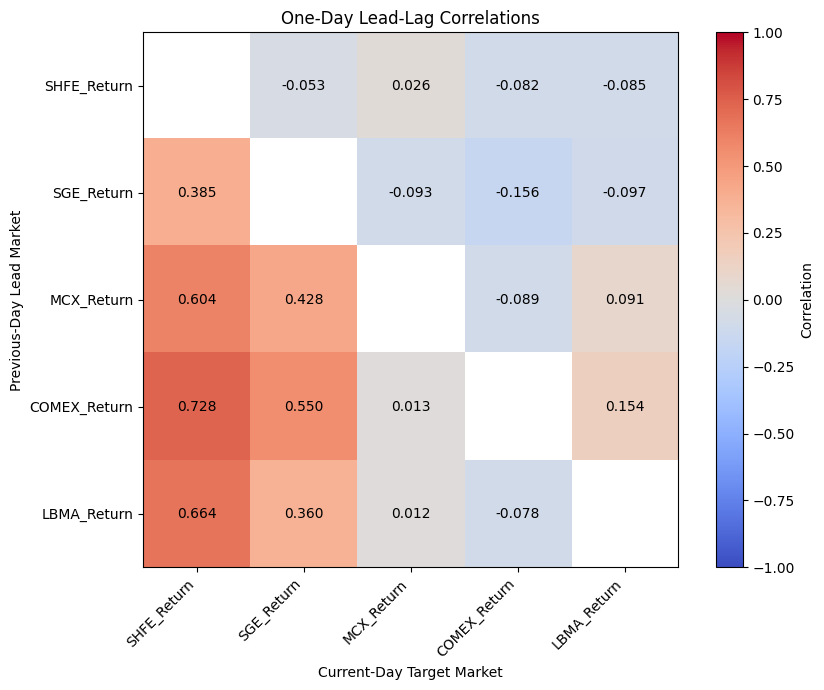

In [87]:
import numpy as np
import matplotlib.pyplot as plt

markets = [
    "SHFE_Return",
    "SGE_Return",
    "MCX_Return",
    "COMEX_Return",
    "LBMA_Return"
]

lag_matrix = np.full((5, 5), np.nan)

for i, lead in enumerate(markets):
    for j, target in enumerate(markets):
        if lead != target:
            value = lag_results[
                (lag_results["Lead"] == lead) &
                (lag_results["Target"] == target)
            ]["Lead_t-1_Target_t"].iloc[0]
            lag_matrix[i, j] = value

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    lag_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(markets, rotation=45, ha="right")
ax.set_yticklabels(markets)

for i in range(5):
    for j in range(5):
        if not np.isnan(lag_matrix[i, j]):
            ax.text(
                j, i,
                f"{lag_matrix[i, j]:.3f}",
                ha="center",
                va="center"
            )

ax.set_xlabel("Current-Day Target Market")
ax.set_ylabel("Previous-Day Lead Market")
ax.set_title("One-Day Lead-Lag Correlations")

fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

In [89]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.3 MB 7.5 MB/s eta 0:00:02
   --------- ------------------------------ 2.6/11.3 MB 7.0 MB/s eta 0:00:02
   -------------- ------------------------- 4.2/11.3 MB 6.9 MB/s eta 0:00:02
   ------------------- -------------------- 5.5/11.3 MB 6.8 MB/s eta 0:00:01
   ------------------------ --------------- 6.8/11.3 MB 6.8 MB/s eta 0:00:01
   ----------------------------- ---------- 8.4/11.3 MB 6.8 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.3 MB 6.8 MB/s eta 0:00:01
   -------------------------------------- - 11.0/11.3 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 6.6 MB/s  0:00:01

   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   --

In [90]:
import statsmodels.api as sm

print("statsmodels version:", sm.__version__)

statsmodels version: 0.15.0


In [93]:
from statsmodels.tsa.stattools import grangercausalitytests

granger_data = common_returns[
    ["SHFE_Return", "COMEX_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: COMEX → SHFE")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: COMEX → SHFE
Lag 1:
  F-statistic = 415.807590
  p-value     = 0.000000

Lag 2:
  F-statistic = 213.180883
  p-value     = 0.000000



In [94]:
granger_data_reverse = common_returns[
    ["COMEX_Return", "SHFE_Return"]
].dropna().copy()

granger_result_reverse = grangercausalitytests(
    granger_data_reverse,
    maxlag=2
)

print("\nGranger Causality Test: SHFE → COMEX")
print("=" * 45)

for lag, result in granger_result_reverse.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: SHFE → COMEX
Lag 1:
  F-statistic = 2.209704
  p-value     = 0.137992

Lag 2:
  F-statistic = 1.122988
  p-value     = 0.326415



In [95]:
granger_data = common_returns[
    ["SGE_Return", "COMEX_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: COMEX → SGE")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: COMEX → SGE
Lag 1:
  F-statistic = 187.598862
  p-value     = 0.000000

Lag 2:
  F-statistic = 97.241430
  p-value     = 0.000000



In [96]:
granger_data_reverse = common_returns[
    ["COMEX_Return", "SGE_Return"]
].dropna().copy()

granger_result_reverse = grangercausalitytests(
    granger_data_reverse,
    maxlag=2
)

print("\nGranger Causality Test: SGE → COMEX")
print("=" * 45)

for lag, result in granger_result_reverse.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: SGE → COMEX
Lag 1:
  F-statistic = 7.042228
  p-value     = 0.008302

Lag 2:
  F-statistic = 3.140475
  p-value     = 0.044421



In [97]:
granger_data = common_returns[
    ["MCX_Return", "COMEX_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: COMEX → MCX")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: COMEX → MCX
Lag 1:
  F-statistic = 1.669470
  p-value     = 0.197132

Lag 2:
  F-statistic = 2.893681
  p-value     = 0.056630



In [98]:
granger_data_reverse = common_returns[
    ["COMEX_Return", "MCX_Return"]
].dropna().copy()

granger_result_reverse = grangercausalitytests(
    granger_data_reverse,
    maxlag=2
)

print("\nGranger Causality Test: MCX → COMEX")
print("=" * 45)

for lag, result in granger_result_reverse.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: MCX → COMEX
Lag 1:
  F-statistic = 0.351945
  p-value     = 0.553375

Lag 2:
  F-statistic = 2.056742
  p-value     = 0.129333



In [99]:
granger_data = common_returns[
    ["LBMA_Return", "COMEX_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: COMEX → LBMA")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: COMEX → LBMA
Lag 1:
  F-statistic = 35.074410
  p-value     = 0.000000

Lag 2:
  F-statistic = 24.551478
  p-value     = 0.000000



In [100]:
granger_data_reverse = common_returns[
    ["COMEX_Return", "LBMA_Return"]
].dropna().copy()

granger_result_reverse = grangercausalitytests(
    granger_data_reverse,
    maxlag=2
)

print("\nGranger Causality Test: LBMA → COMEX")
print("=" * 45)

for lag, result in granger_result_reverse.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: LBMA → COMEX
Lag 1:
  F-statistic = 0.143020
  p-value     = 0.705513

Lag 2:
  F-statistic = 0.000238
  p-value     = 0.999762



In [101]:
granger_data = common_returns[
    ["SHFE_Return", "LBMA_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: LBMA → SHFE")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: LBMA → SHFE
Lag 1:
  F-statistic = 288.622617
  p-value     = 0.000000

Lag 2:
  F-statistic = 142.666582
  p-value     = 0.000000



In [102]:
granger_data = common_returns[
    ["LBMA_Return", "SHFE_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: SHFE → LBMA")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: SHFE → LBMA
Lag 1:
  F-statistic = 2.124803
  p-value     = 0.145775

Lag 2:
  F-statistic = 1.283166
  p-value     = 0.278392



In [103]:
granger_data = common_returns[
    ["SHFE_Return", "SGE_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: SGE → SHFE")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: SGE → SHFE
Lag 1:
  F-statistic = 87.649254
  p-value     = 0.000000

Lag 2:
  F-statistic = 44.166802
  p-value     = 0.000000



In [104]:
granger_data = common_returns[
    ["SGE_Return", "SHFE_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: SHFE → SGE")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()
    


Granger Causality Test: SHFE → SGE
Lag 1:
  F-statistic = 1.687503
  p-value     = 0.194735

Lag 2:
  F-statistic = 0.567721
  p-value     = 0.567310



In [105]:
granger_data = common_returns[
    ["SHFE_Return", "MCX_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: MCX → SHFE")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: MCX → SHFE
Lag 1:
  F-statistic = 207.799024
  p-value     = 0.000000

Lag 2:
  F-statistic = 105.510534
  p-value     = 0.000000



In [106]:
granger_data = common_returns[
    ["MCX_Return", "SHFE_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: SHFE → MCX")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: SHFE → MCX
Lag 1:
  F-statistic = 0.339047
  p-value     = 0.560732

Lag 2:
  F-statistic = 1.863767
  p-value     = 0.156544



In [107]:
granger_data = common_returns[
    ["MCX_Return", "SGE_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: SGE → MCX")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: SGE → MCX
Lag 1:
  F-statistic = 2.881749
  p-value     = 0.090425

Lag 2:
  F-statistic = 5.266001
  p-value     = 0.005559



In [108]:
granger_data = common_returns[
    ["SGE_Return", "MCX_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: MCX → SGE")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: MCX → SGE
Lag 1:
  F-statistic = 99.646160
  p-value     = 0.000000

Lag 2:
  F-statistic = 52.812240
  p-value     = 0.000000



In [109]:
granger_data = common_returns[
    ["SGE_Return", "LBMA_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: LBMA → SGE")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: LBMA → SGE
Lag 1:
  F-statistic = 74.700864
  p-value     = 0.000000

Lag 2:
  F-statistic = 37.216989
  p-value     = 0.000000



In [110]:
granger_data = common_returns[
    ["LBMA_Return", "SGE_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: SGE → LBMA")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: SGE → LBMA
Lag 1:
  F-statistic = 2.581969
  p-value     = 0.108936

Lag 2:
  F-statistic = 0.594811
  p-value     = 0.552195



In [111]:
granger_data = common_returns[
    ["MCX_Return", "LBMA_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: LBMA → MCX")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: LBMA → MCX
Lag 1:
  F-statistic = 0.674344
  p-value     = 0.412067

Lag 2:
  F-statistic = 0.189571
  p-value     = 0.827394



In [112]:
granger_data = common_returns[
    ["LBMA_Return", "MCX_Return"]
].dropna().copy()

granger_result = grangercausalitytests(
    granger_data,
    maxlag=2
)

print("\nGranger Causality Test: MCX → LBMA")
print("=" * 45)

for lag, result in granger_result.items():
    test_stat = result[0]["ssr_ftest"]
    print(f"Lag {lag}:")
    print(f"  F-statistic = {test_stat[0]:.6f}")
    print(f"  p-value     = {test_stat[1]:.6f}")
    print()


Granger Causality Test: MCX → LBMA
Lag 1:
  F-statistic = 10.657817
  p-value     = 0.001198

Lag 2:
  F-statistic = 11.119098
  p-value     = 0.000020



In [113]:
from statsmodels.tsa.stattools import adfuller

var_data = common_returns[
    ["SHFE_Return", "SGE_Return", "MCX_Return", "COMEX_Return", "LBMA_Return"]
].copy()

print("VAR dataset shape:", var_data.shape)
print()

for column in var_data.columns:
    result = adfuller(var_data[column])
    print(f"{column}:")
    print(f"  ADF statistic = {result[0]:.6f}")
    print(f"  p-value       = {result[1]:.6f}")
    print()

VAR dataset shape: (376, 5)

SHFE_Return:
  ADF statistic = -6.424491
  p-value       = 0.000000

SGE_Return:
  ADF statistic = -7.539124
  p-value       = 0.000000

MCX_Return:
  ADF statistic = -12.396400
  p-value       = 0.000000

COMEX_Return:
  ADF statistic = -7.451824
  p-value       = 0.000000

LBMA_Return:
  ADF statistic = -5.348298
  p-value       = 0.000004



C:\Users\Divesh\AppData\Local\Temp\ipykernel_14732\2077495619.py:11: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(var_data[column])
C:\Users\Divesh\AppData\Local\Temp\ipykernel_14732\2077495619.py:11: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(var_data[column])
C:\Users\Divesh\AppData\Local\Temp\ipykernel_14732\2077495619.py:11: Fut

In [114]:
from statsmodels.tsa.api import VAR

model = VAR(var_data)

lag_selection = model.select_order(maxlags=10)

print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -51.30      -51.24   5.272e-23      -51.28
1       -52.64     -52.32*   1.381e-23      -52.51
2       -52.75      -52.16   1.238e-23     -52.51*
3      -52.80*      -51.95  1.175e-23*      -52.46
4       -52.74      -51.62   1.249e-23      -52.29
5       -52.75      -51.36   1.235e-23      -52.20
6       -52.69      -51.04   1.313e-23      -52.03
7       -52.67      -50.75   1.344e-23      -51.90
8       -52.63      -50.45   1.394e-23      -51.76
9       -52.64      -50.18   1.390e-23      -51.66
10      -52.59      -49.88   1.454e-23      -51.51
--------------------------------------------------


C:\Users\Divesh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)


In [115]:
var_data = common_returns[
    ["Date", "SHFE_Return", "SGE_Return", "MCX_Return", "COMEX_Return", "LBMA_Return"]
].copy()

var_data = var_data.set_index("Date").asfreq("B")

print(var_data.shape)
print(var_data.head())

(433, 5)
            SHFE_Return  SGE_Return  MCX_Return  COMEX_Return  LBMA_Return
Date                                                                      
2023-01-04     0.003990    0.003833    0.004268      0.007121     0.007622
2023-01-05     0.004653   -0.002682   -0.008553     -0.009715    -0.012545
2023-01-06    -0.010035   -0.008189    0.008193      0.016023     0.009924
2023-01-09     0.004630    0.009943    0.002171      0.004560     0.014388
2023-01-10     0.002474    0.001717   -0.002721     -0.000587    -0.000106


In [116]:
var_data = common_returns[
    ["Date", "SHFE_Return", "SGE_Return", "MCX_Return", "COMEX_Return", "LBMA_Return"]
].copy()

var_data = var_data.set_index("Date")

print(var_data.shape)
print(var_data.head())
print(var_data.tail())

(376, 5)
            SHFE_Return  SGE_Return  MCX_Return  COMEX_Return  LBMA_Return
Date                                                                      
2023-01-04     0.003990    0.003833    0.004268      0.007121     0.007622
2023-01-05     0.004653   -0.002682   -0.008553     -0.009715    -0.012545
2023-01-06    -0.010035   -0.008189    0.008193      0.016023     0.009924
2023-01-09     0.004630    0.009943    0.002171      0.004560     0.014388
2023-01-10     0.002474    0.001717   -0.002721     -0.000587    -0.000106
            SHFE_Return  SGE_Return  MCX_Return  COMEX_Return  LBMA_Return
Date                                                                      
2024-08-23    -0.005434   -0.002287    0.008189      0.011900     0.011357
2024-08-27     0.002193   -0.001566    0.001152     -0.000675    -0.001055
2024-08-28     0.000139   -0.001150   -0.005255     -0.005962    -0.001316
2024-08-29    -0.000660    0.002738    0.006203      0.009876     0.005129
2024-08-30    -0

In [117]:
from statsmodels.tsa.api import VAR

var_model = VAR(var_data)
var_result = var_model.fit(1)

print(var_result.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 14, Sep, 2026
Time:                     23:50:52
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -52.3664
Nobs:                     375.000    HQIC:                  -52.5558
Log likelihood:           7247.09    FPE:                1.32170e-23
AIC:                     -52.6806    Det(Omega_mle):     1.22085e-23
--------------------------------------------------------------------
Results for equation SHFE_Return
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.000314         0.000219            1.432           0.152
L1.SHFE_Return         -0.129618         0.048080           -2.696           0.007
L1.SGE_Return           0.192383         0.042

C:\Users\Divesh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


In [118]:
print("VAR stability:", var_result.is_stable())

VAR stability: True


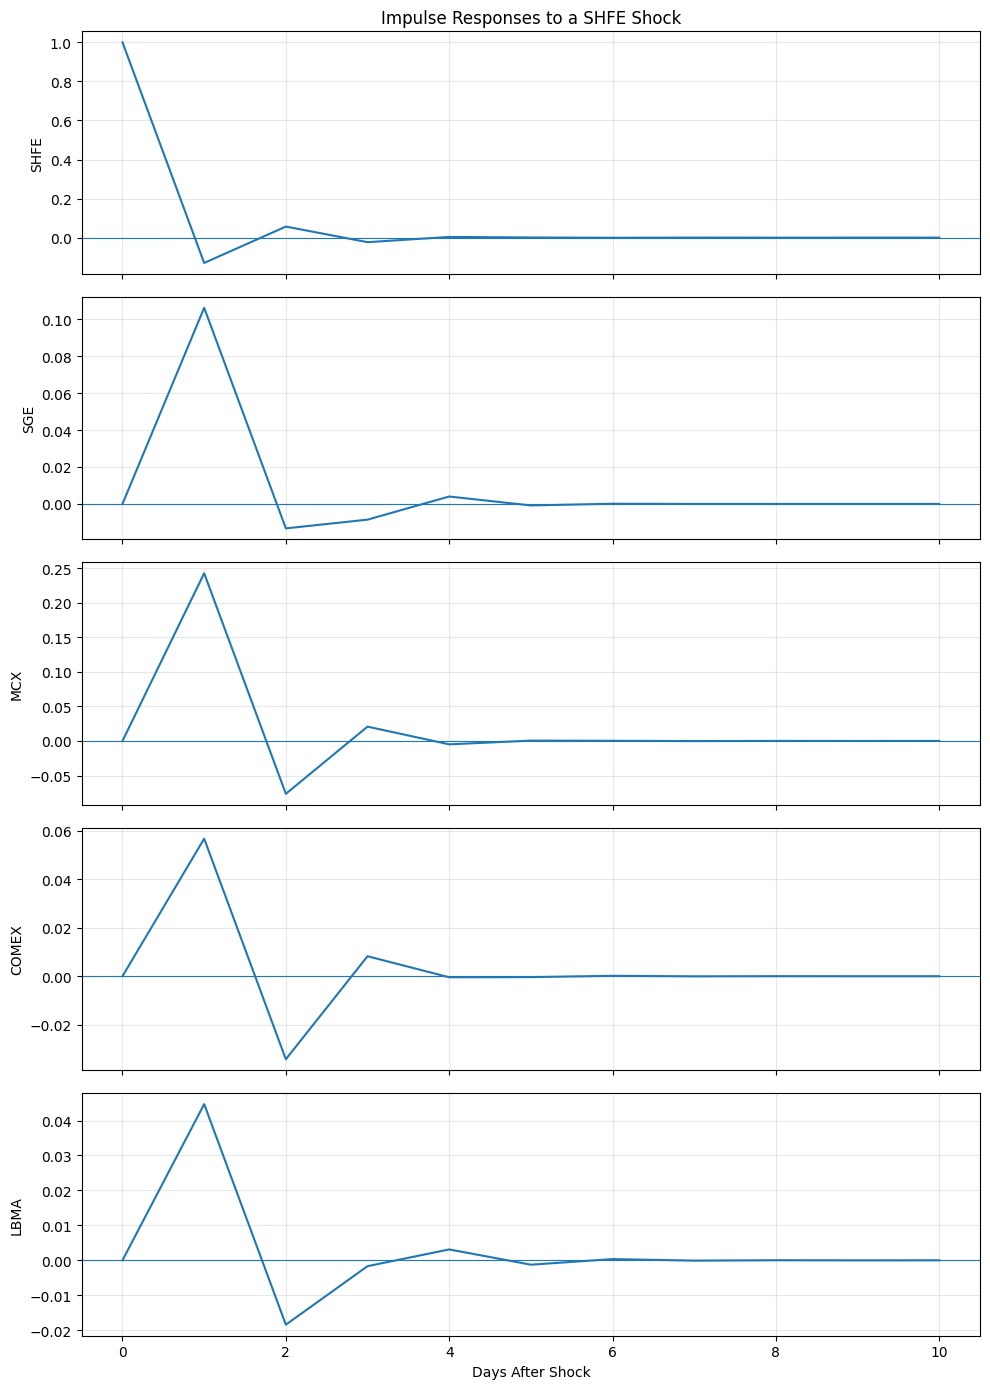

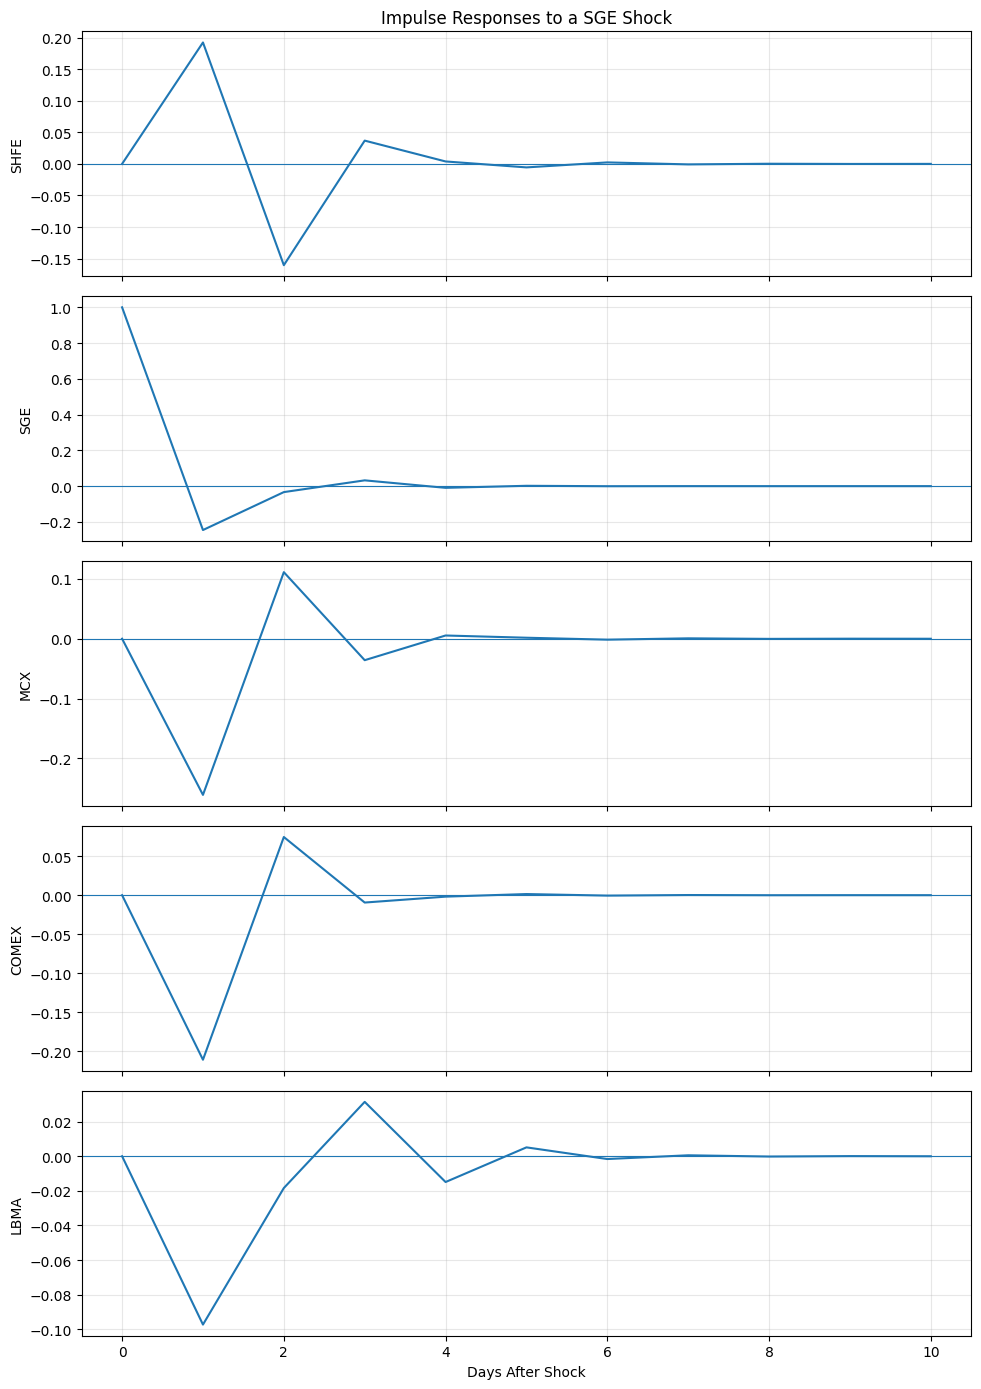

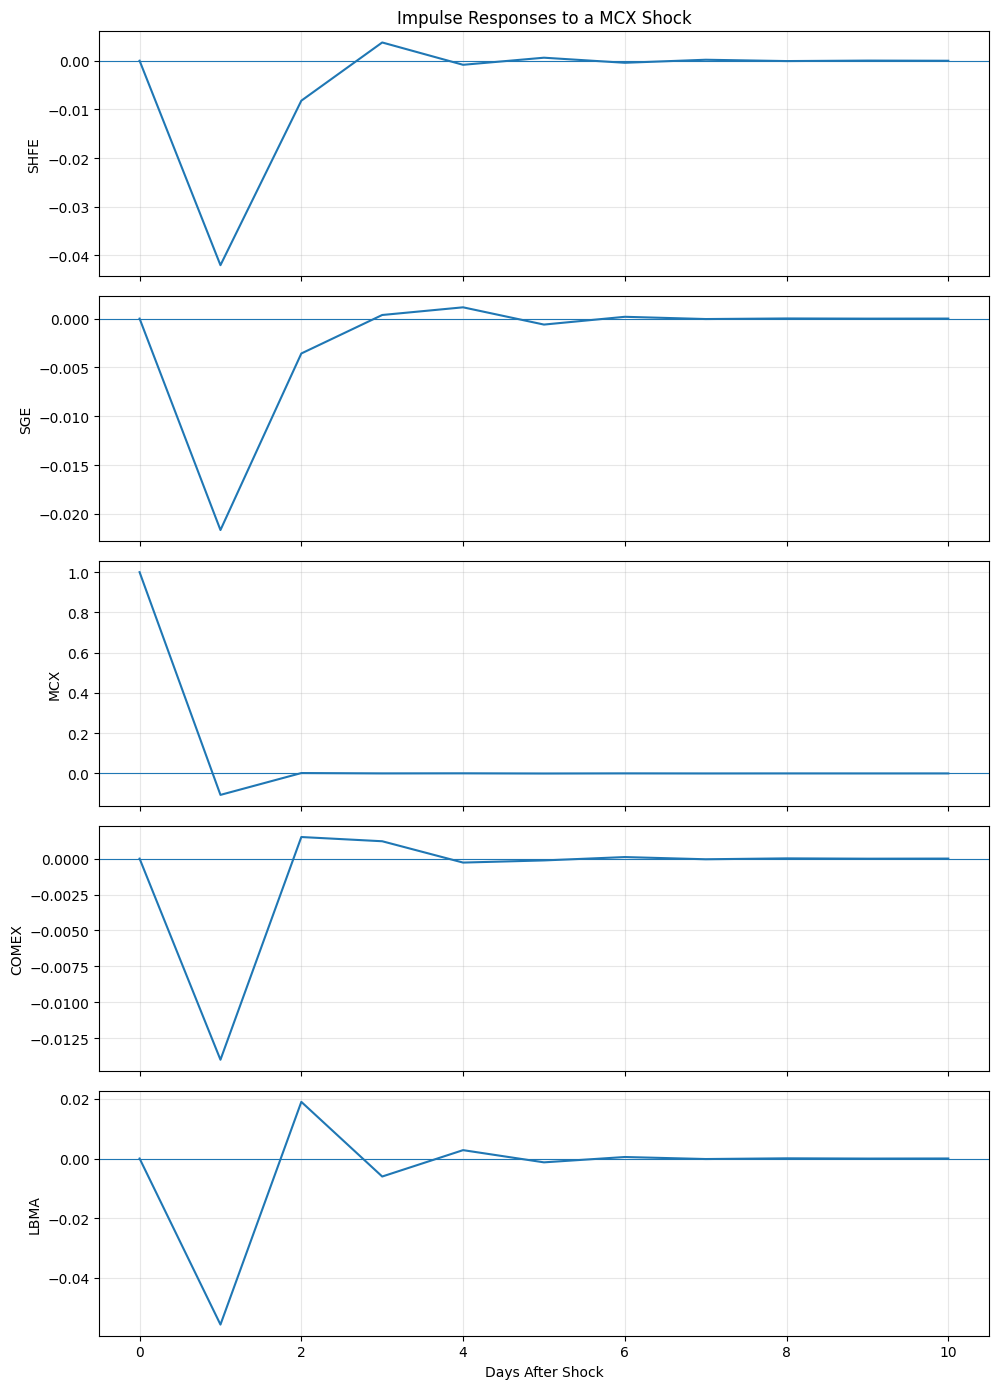

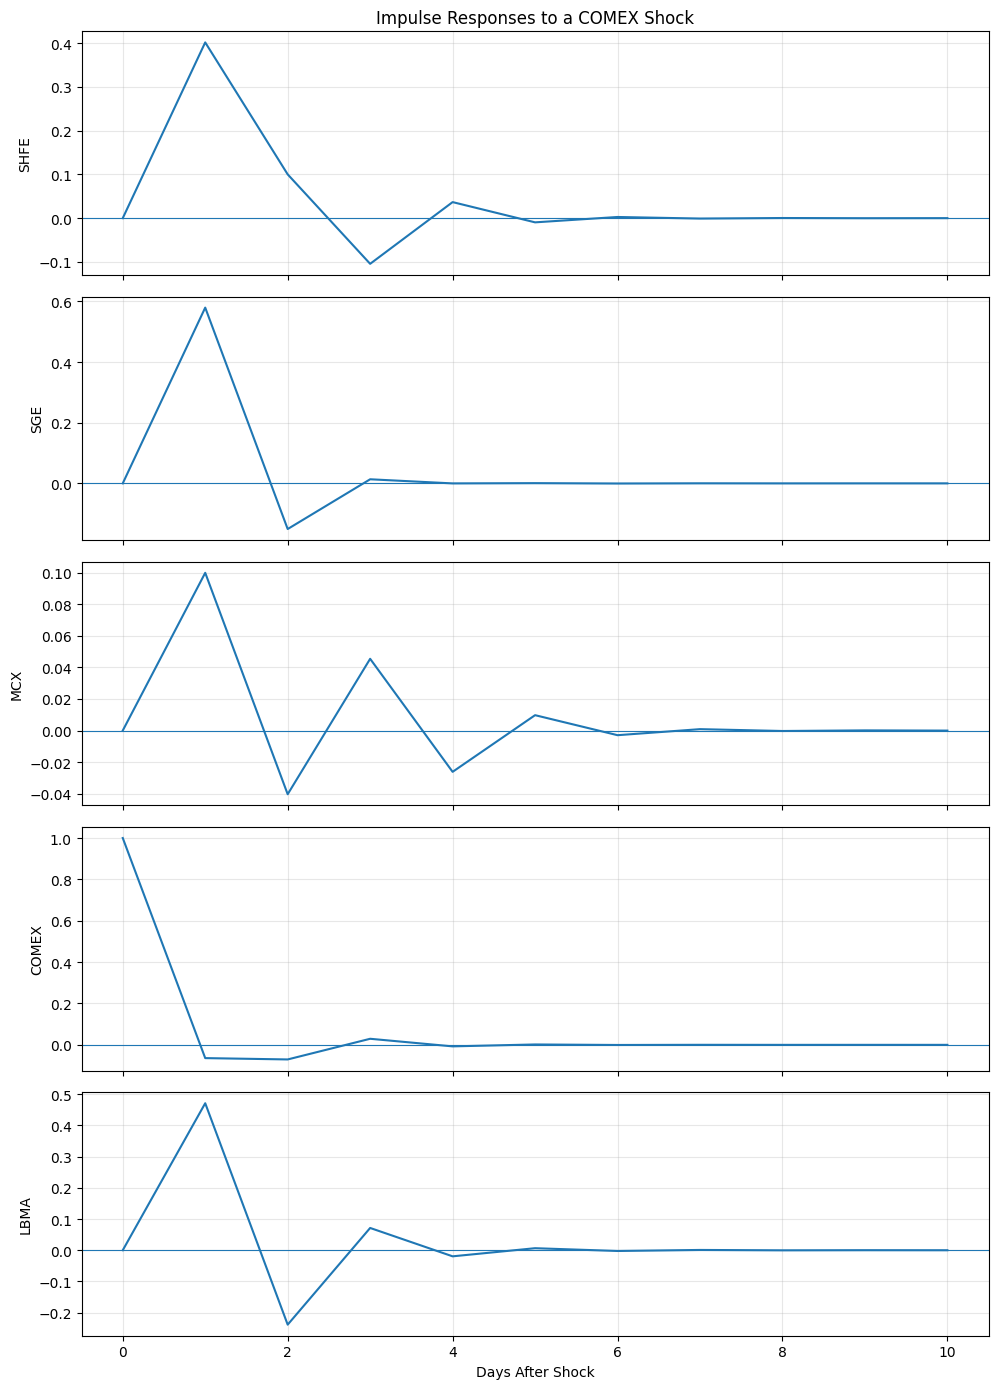

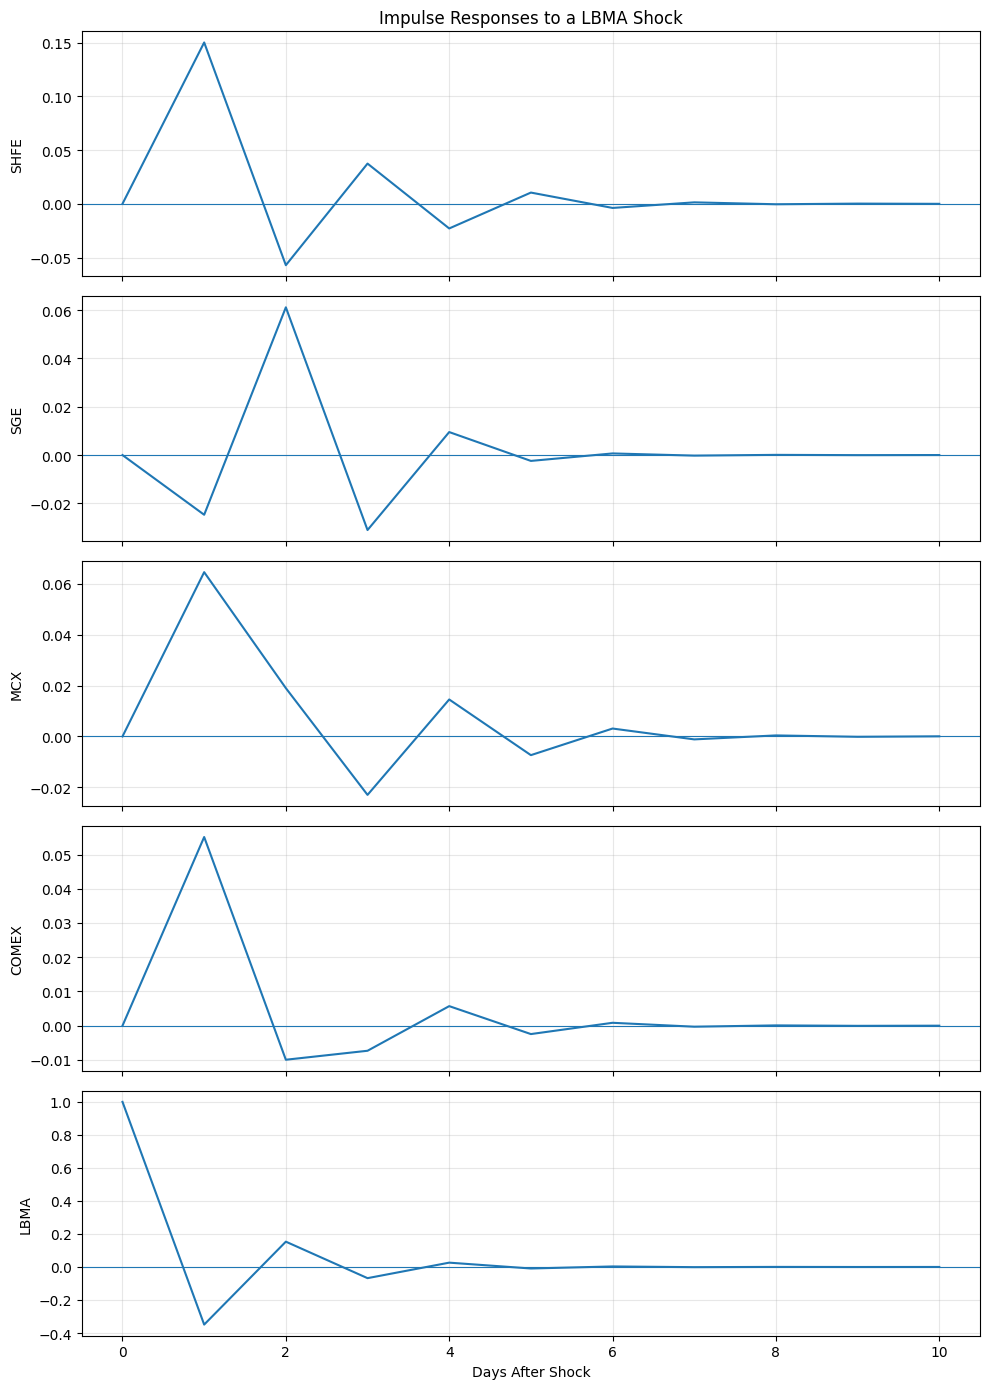

In [120]:
import matplotlib.pyplot as plt

markets = ["SHFE", "SGE", "MCX", "COMEX", "LBMA"]

irf = var_result.irf(10)

for i, shock in enumerate(markets):
    fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

    for j, response in enumerate(markets):
        axes[j].plot(irf.irfs[:, j, i])
        axes[j].axhline(0, linewidth=0.8)
        axes[j].set_ylabel(response)
        axes[j].grid(True, alpha=0.3)

    axes[0].set_title(f"Impulse Responses to a {shock} Shock")
    axes[-1].set_xlabel("Days After Shock")

    plt.tight_layout()
    plt.show()

In [121]:
selected_days = [0, 1, 2, 5, 10]

for i, shock in enumerate(markets):
    print("\n" + "=" * 70)
    print(f"SHOCK: {shock}")
    print("=" * 70)

    table = pd.DataFrame(
        irf.irfs[selected_days, :, i],
        index=selected_days,
        columns=markets
    )

    print(table.round(6))


SHOCK: SHFE
        SHFE       SGE       MCX     COMEX      LBMA
0   1.000000  0.000000  0.000000  0.000000  0.000000
1  -0.129618  0.106144  0.242611  0.056825  0.044697
2   0.056576 -0.013244 -0.076455 -0.034305 -0.018420
5   0.000805 -0.000829  0.000502 -0.000372 -0.001251
10 -0.000004  0.000000  0.000004  0.000001  0.000003

SHOCK: SGE
        SHFE       SGE       MCX     COMEX      LBMA
0   0.000000  1.000000  0.000000  0.000000  0.000000
1   0.192383 -0.245494 -0.260916 -0.210675 -0.097251
2  -0.160480 -0.033352  0.111231  0.074453 -0.018378
5  -0.005549  0.001902  0.001688  0.001443  0.005110
10  0.000025 -0.000004 -0.000024 -0.000005 -0.000023

SHOCK: MCX
        SHFE       SGE       MCX     COMEX      LBMA
0   0.000000  0.000000  1.000000  0.000000  0.000000
1  -0.042018 -0.021662 -0.106652 -0.014004 -0.055600
2  -0.008212 -0.003574  0.001847  0.001503  0.018961
5   0.000618 -0.000613 -0.000409 -0.000126 -0.001286
10 -0.000009  0.000002  0.000008  0.000002  0.000008

SHOCK: C

In [122]:
fevd = var_result.fevd(10)

print(fevd.summary())

FEVD for SHFE_Return
     SHFE_Return  SGE_Return  MCX_Return  COMEX_Return  LBMA_Return
0       1.000000    0.000000    0.000000      0.000000     0.000000
1       0.472932    0.147950    0.221444      0.144569     0.013105
2       0.466266    0.155959    0.219303      0.143782     0.014690
3       0.461793    0.154431    0.222484      0.145958     0.015335
4       0.461361    0.154347    0.222611      0.146066     0.015615
5       0.461326    0.154348    0.222594      0.146057     0.015675
6       0.461322    0.154347    0.222592      0.146056     0.015683
7       0.461321    0.154347    0.222591      0.146056     0.015684
8       0.461321    0.154347    0.222591      0.146056     0.015684
9       0.461321    0.154347    0.222591      0.146056     0.015684

FEVD for SGE_Return
     SHFE_Return  SGE_Return  MCX_Return  COMEX_Return  LBMA_Return
0       0.412088    0.587912    0.000000      0.000000     0.000000
1       0.281714    0.397909    0.197818      0.122322     0.000237
2     

In [123]:
var_data_reordered = var_data[
    ["COMEX_Return", "LBMA_Return", "MCX_Return", "SGE_Return", "SHFE_Return"]
].copy()

var_model_reordered = VAR(var_data_reordered)
var_result_reordered = var_model_reordered.fit(1)

fevd_reordered = var_result_reordered.fevd(10)

print(fevd_reordered.summary())

FEVD for COMEX_Return
     COMEX_Return  LBMA_Return  MCX_Return  SGE_Return  SHFE_Return
0        1.000000     0.000000    0.000000    0.000000     0.000000
1        0.985053     0.000018    0.000371    0.014143     0.000414
2        0.983498     0.000025    0.000391    0.015524     0.000562
3        0.983461     0.000048    0.000391    0.015529     0.000571
4        0.983451     0.000056    0.000391    0.015531     0.000571
5        0.983449     0.000057    0.000391    0.015531     0.000571
6        0.983449     0.000058    0.000391    0.015532     0.000571
7        0.983449     0.000058    0.000391    0.015532     0.000571
8        0.983449     0.000058    0.000391    0.015532     0.000571
9        0.983449     0.000058    0.000391    0.015532     0.000571

FEVD for LBMA_Return
     COMEX_Return  LBMA_Return  MCX_Return  SGE_Return  SHFE_Return
0        0.639042     0.360958    0.000000    0.000000     0.000000
1        0.614766     0.381210    0.001080    0.002669     0.000275
2   

C:\Users\Divesh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


In [124]:
print(var_result.test_whiteness(nlags=10).summary())

Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         344.2          261.0   0.000 225
-----------------------------------------


In [125]:
from statsmodels.tsa.api import VAR

for lag in [1, 2, 3]:

    model = VAR(var_data)
    result = model.fit(lag)

    test = result.test_whiteness(nlags=10)

    print("=" * 60)
    print(f"VAR({lag})")
    print("=" * 60)
    print(test.summary())

VAR(1)
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         344.2          261.0   0.000 225
-----------------------------------------
VAR(2)
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         282.9          234.0   0.000 200
-----------------------------------------
VAR(3)
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         233.9          206.9   0.002 175
-----------------------------------------


C:\Users\Divesh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
C:\Users\Divesh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
C:\Users\Divesh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


In [127]:
for lag in range(4, 11):
    test = var3_result.test_whiteness(nlags=lag)
    print(f"Lag {lag}: p-value = {test.pvalue:.6f}")

Lag 4: p-value = 0.003947
Lag 5: p-value = 0.001801
Lag 6: p-value = 0.008056
Lag 7: p-value = 0.026195
Lag 8: p-value = 0.002476
Lag 9: p-value = 0.001986
Lag 10: p-value = 0.001946


In [128]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(var3_result.resid)

for market, value in zip(var_data.columns, dw):
    print(f"{market}: Durbin-Watson = {value:.4f}")

SHFE_Return: Durbin-Watson = 2.0141
SGE_Return: Durbin-Watson = 2.0141
MCX_Return: Durbin-Watson = 2.0060
COMEX_Return: Durbin-Watson = 1.9965
LBMA_Return: Durbin-Watson = 1.9943


In [129]:
print(var3_result.test_normality().summary())

normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
     3.161e+04          18.31   0.000 10
----------------------------------------


In [130]:
var4_model = VAR(var_data)
var4_result = var4_model.fit(4)

print(var4_result.test_whiteness(nlags=10).summary())

Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         208.1          179.6   0.001 150
-----------------------------------------


C:\Users\Divesh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


In [131]:
var3_irf = var3_result.irf(10)

markets = ["SHFE", "SGE", "MCX", "COMEX", "LBMA"]

for i, shock in enumerate(markets):

    print("\n" + "=" * 70)
    print(f"SHOCK: {shock}")
    print("=" * 70)

    for j, response in enumerate(markets):

        if shock == response:
            continue

        values = var3_irf.irfs[:, j, i]

        day1 = values[1]
        day5 = values[5]
        day10 = values[10]

        print(
            f"{shock} → {response}: "
            f"Day 1 = {day1:.6f}, "
            f"Day 5 = {day5:.6f}, "
            f"Day 10 = {day10:.6f}"
        )


SHOCK: SHFE
SHFE → SGE: Day 1 = 0.154239, Day 5 = 0.037031, Day 10 = -0.003516
SHFE → MCX: Day 1 = 0.199218, Day 5 = 0.025458, Day 10 = -0.004319
SHFE → COMEX: Day 1 = 0.084130, Day 5 = 0.026295, Day 10 = -0.001005
SHFE → LBMA: Day 1 = 0.110406, Day 5 = 0.064269, Day 10 = -0.001265

SHOCK: SGE
SGE → SHFE: Day 1 = 0.228357, Day 5 = 0.039358, Day 10 = -0.006511
SGE → MCX: Day 1 = -0.261271, Day 5 = -0.060867, Day 10 = 0.007504
SGE → COMEX: Day 1 = -0.238753, Day 5 = -0.045369, Day 10 = 0.000955
SGE → LBMA: Day 1 = -0.216487, Day 5 = -0.065129, Day 10 = -0.001911

SHOCK: MCX
MCX → SHFE: Day 1 = -0.046398, Day 5 = 0.012703, Day 10 = -0.002291
MCX → SGE: Day 1 = -0.001675, Day 5 = 0.012499, Day 10 = 0.001709
MCX → COMEX: Day 1 = -0.009629, Day 5 = 0.005338, Day 10 = 0.001585
MCX → LBMA: Day 1 = -0.045929, Day 5 = 0.019177, Day 10 = 0.001489

SHOCK: COMEX
COMEX → SHFE: Day 1 = 0.447906, Day 5 = -0.022823, Day 10 = 0.003951
COMEX → SGE: Day 1 = 0.638989, Day 5 = 0.035123, Day 10 = -0.006234


In [132]:
var3_fevd = var3_result.fevd(10)

print(var3_fevd.summary())

FEVD for SHFE_Return
     SHFE_Return  SGE_Return  MCX_Return  COMEX_Return  LBMA_Return
0       1.000000    0.000000    0.000000      0.000000     0.000000
1       0.453695    0.149199    0.234875      0.156318     0.005914
2       0.441067    0.147908    0.237719      0.152897     0.020409
3       0.435213    0.146014    0.237477      0.160867     0.020429
4       0.429778    0.144076    0.235392      0.167026     0.023728
5       0.428678    0.143805    0.235757      0.167620     0.024139
6       0.428404    0.143930    0.235743      0.167728     0.024195
7       0.428326    0.143990    0.235743      0.167712     0.024228
8       0.428316    0.144017    0.235733      0.167705     0.024229
9       0.428298    0.144026    0.235724      0.167712     0.024240

FEVD for SGE_Return
     SHFE_Return  SGE_Return  MCX_Return  COMEX_Return  LBMA_Return
0       0.464564    0.535436    0.000000      0.000000     0.000000
1       0.298625    0.341753    0.226566      0.130208     0.002848
2     

In [133]:
mcx_outliers = common_returns.loc[
    common_returns["MCX_Return"].abs().nlargest(10).index,
    ["Date", "MCX_Return", "COMEX_Return", "LBMA_Return", "SGE_Return", "SHFE_Return"]
]

print(mcx_outliers.sort_values("Date").to_string(index=False))

      Date  MCX_Return  COMEX_Return  LBMA_Return  SGE_Return  SHFE_Return
2023-03-13    0.026572      0.026692     0.026891    0.008905     0.008348
2023-03-17    0.023739      0.026472     0.020465    0.004950     0.000510
2023-10-13    0.025726      0.031081     0.018783    0.006518     0.003228
2023-12-14    0.020507      0.024164     0.032081    0.019356     0.007325
2024-03-28    0.019739      0.012234     0.009874    0.005543     0.002904
2024-04-22   -0.022100     -0.027602    -0.018805   -0.015914    -0.005038
2024-05-23   -0.020111     -0.022685    -0.020993   -0.020893    -0.018270
2024-06-07   -0.024313     -0.027465    -0.021096    0.000965     0.005578
2024-07-23   -0.057867      0.005268     0.004347   -0.005894    -0.000071
2024-07-25   -0.021609     -0.025442    -0.023643   -0.024631    -0.006176


In [134]:
mcx_refined_raw[
    mcx_refined_raw["Date"].isin(["23-07-2024", "22-07-2024", "24-07-2024"])
][["Date", "Price", "Open", "High", "Low", "Change %"]]

,Date,Price,Open,High,Low,Change %
26,24-07-2024,"68,952","68,790","69,299","68,652",0.65%
27,23-07-2024,"68,510","72,838","72,850","68,456",-5.79%
28,22-07-2024,"72,718","73,161","73,185","72,501",-0.37%


In [135]:
# Create robustness dataset without modifying the original var_data
var_data_robust = var_data.drop(
    pd.Timestamp("2024-07-23")
).copy()

print("Original observations:", len(var_data))
print("Robustness observations:", len(var_data_robust))

# Fit VAR(3) on the robustness sample
var3_robust_model = VAR(var_data_robust)
var3_robust_result = var3_robust_model.fit(3)

print(var3_robust_result.summary())

Original observations: 376
Robustness observations: 375
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 15, Sep, 2026
Time:                     00:08:57
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -52.7253
Nobs:                     372.000    HQIC:                  -53.2334
Log likelihood:           7404.44    FPE:                5.44239e-24
AIC:                     -53.5681    Det(Omega_mle):     4.40906e-24
--------------------------------------------------------------------
Results for equation SHFE_Return
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.000313         0.000221            1.413           0.158
L1.SHFE_Return         -0.249757         0.069373           -3.600       

C:\Users\Divesh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


In [136]:
print("VAR(3) robustness stability:", var3_robust_result.is_stable())

VAR(3) robustness stability: True


In [137]:
var3_robust_irf = var3_robust_result.irf(10)

markets = ["SHFE", "SGE", "MCX", "COMEX", "LBMA"]

for i, shock in enumerate(markets):

    print("\n" + "=" * 70)
    print(f"SHOCK: {shock}")
    print("=" * 70)

    for j, response in enumerate(markets):

        if shock == response:
            continue

        values = var3_robust_irf.irfs[:, j, i]

        print(
            f"{shock} → {response}: "
            f"Day 1 = {values[1]:.6f}, "
            f"Day 5 = {values[5]:.6f}, "
            f"Day 10 = {values[10]:.6f}"
        )


SHOCK: SHFE
SHFE → SGE: Day 1 = 0.124045, Day 5 = 0.044592, Day 10 = -0.000382
SHFE → MCX: Day 1 = 0.107181, Day 5 = 0.011445, Day 10 = 0.001258
SHFE → COMEX: Day 1 = 0.070640, Day 5 = 0.018659, Day 10 = 0.002140
SHFE → LBMA: Day 1 = 0.095936, Day 5 = 0.058398, Day 10 = 0.000541

SHOCK: SGE
SGE → SHFE: Day 1 = 0.240823, Day 5 = -0.003579, Day 10 = -0.003184
SGE → MCX: Day 1 = -0.185348, Day 5 = -0.007311, Day 10 = 0.000226
SGE → COMEX: Day 1 = -0.248361, Day 5 = -0.015715, Day 10 = -0.001925
SGE → LBMA: Day 1 = -0.224199, Day 5 = -0.042568, Day 10 = -0.003696

SHOCK: MCX
MCX → SHFE: Day 1 = -0.066430, Day 5 = 0.033467, Day 10 = -0.001162
MCX → SGE: Day 1 = 0.070044, Day 5 = 0.043249, Day 10 = -0.003375
MCX → COMEX: Day 1 = 0.024986, Day 5 = -0.014267, Day 10 = 0.003707
MCX → LBMA: Day 1 = 0.021075, Day 5 = 0.017677, Day 10 = 0.001044

SHOCK: COMEX
COMEX → SHFE: Day 1 = 0.465437, Day 5 = -0.033857, Day 10 = 0.000275
COMEX → SGE: Day 1 = 0.591467, Day 5 = -0.003850, Day 10 = -0.000101
C